In [2]:
import numpy as np
from matplotlib import pyplot as plt
import scipy.io
from scipy.stats import spearmanr, pearsonr

#=================================================================================================#

from utils import interventional as IC
from utils import load_data as ld
from utils import load_EC as lec
from utils import colormaps as maps
from utils import plot as pl
from utils import correlations as cc
from utils import distance as di

#=================================================================================================#

In [3]:
#=================================================================================================#
# For Avenir font. To use it, you have to download the font-style files below.
# Comment the lines referred to fontManager if you don't need to set the font.
from matplotlib import font_manager, rcParams
font_file   = "/home/tentori/.local/avenir_ff/AvenirLTStd-Roman.otf"
font_file_b = "/home/tentori/.local/avenir_ff/AvenirLTStd-Black.otf"
font_file_c = "/home/tentori/.local/avenir_ff/AvenirLTStd-Book.otf"
font_manager.fontManager.addfont(font_file)
font_manager.fontManager.addfont(font_file_b)
font_manager.fontManager.addfont(font_file_c)
#------------------------------------------------------------#
rcParams['font.family']  = "Avenir LT Std"
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype']  = 42
#------------------------------------------------------------#
DIM = 25
plt.rcParams.update({'font.size': DIM,'axes.labelsize': DIM,'axes.titlesize': DIM,'xtick.labelsize': DIM,'ytick.labelsize': DIM})
#=================================================================================================#
# Colors
colorz    = ['#255D93','#5FA6D6','#B02106','#F24D33','#2C2C2C','#787878']
coldhot_cmap   = maps.create_cmaphot()
coldhot_cmap_r = maps.create_cmaphot_r()
#------------------------------------------------------------#
show_plot   = True
#------------------------------------------------------------#
from cmap import Colormap
def Cmap(cmap):
    return Colormap(cmap).to_mpl()
#------------------------------------------------------------#
def truncate_cmap(cmap, minval=0.0, maxval=0.8, n=256):
    from matplotlib.colors import Normalize, LinearSegmentedColormap
    return LinearSegmentedColormap.from_list( f'{cmap.name}_trunc', cmap(np.linspace(minval, maxval, n)) )
#------------------------------------------------------------#
def discrete_cmap(cmap_name='turbo', num_colors=25, minval=0., maxval=1):
    from matplotlib.colors import ListedColormap
    base = truncate_cmap(plt.get_cmap(cmap_name), minval=minval, maxval=maxval)
    return ListedColormap(base(np.linspace(0, 1, num_colors)))
cmap=truncate_cmap(plt.get_cmap('Blues'), minval=0.1, maxval=1)
#=================================================================================================#
# to create folder
def Set_Dir_Plots(path):
    import os
    if not os.path.exists(path):
        os.mkdir(path)
#=================================================================================================#


## Functions

In [4]:
def ic_save(_path_,ic,ic_pval,ic_pval_FDR,suffix=''):
    
    import pickle
    with open(_path_+'ks'+suffix+'.pkl', 'wb') as f:
        pickle.dump(ic, f)

    with open(_path_+'ks_pval'+suffix+'.pkl', 'wb') as f:
        pickle.dump(ic_pval, f)

    with open(_path_+'ks_pval_FDR'+suffix+'.pkl', 'wb') as f:
        pickle.dump(ic_pval_FDR, f)
        
def ic_load(_path_,suffix=''):
    
    with open(_path_+'ks'+suffix+'.pkl', 'rb') as f:
        ic = pickle.load(f)

    with open(_path_+'ks_pval'+suffix+'.pkl', 'rb') as f:
        ic_pval = pickle.load(f)
        
    with open(_path_+'ks_pval_FDR'+suffix+'.pkl', 'rb') as f:
        ic_pval_FDR = pickle.load(f)
        
    return ic, ic_pval, ic_pval_FDR

In [5]:
def violin_compare(v1, v2, ax=None, *, xlabels=('Culture 1', 'Culture 2'),
                    point_color1='tab:red', point_alpha1=0.95, point_color2='tab:red', point_alpha2=0.30,
                    point_size=30, point_edgecolor1='white', point_edgecolor2='k', point_edgewidth=0.5, jitter=0.08, seed=0,
                    widths=0.6, violin_facecolors=('none', 'none'), violin_edgecolors=('black', 'black'),
                    violin_alphas=(0.15, 0.15), show_means=True, show_extrema=True, show_medians=False, bar_color='black', 
                    bar_linewidth=1.5, bar_alpha=0.9, ylabel=r'$\rho_{sp}(\mathrm{IC}, \mathrm{TE})$', title=None, ylim=(None, None), grid_y=True):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))

    data = [np.asarray(v1), np.asarray(v2)]
    pos = [0, 1]

    # Draw violins
    vp = ax.violinplot(data, positions=pos, widths=widths, showmeans=show_means, showextrema=show_extrema, showmedians=show_medians)

    # Customize each violin body
    for k, body in enumerate(vp['bodies']):
        body.set_facecolor(violin_facecolors[k])
        body.set_edgecolor(violin_edgecolors[k])
        body.set_alpha(violin_alphas[k])
        body.set_linewidth(1.5)

    # Customize the bars/lines that violinplot adds
    for key in ('cmeans', 'cmaxes', 'cmins', 'cbars', 'cmedians'):
        if key in vp and vp[key] is not None:
            try:
                vp[key].set_color(bar_color)
                vp[key].set_alpha(bar_alpha)
                vp[key].set_linewidth(bar_linewidth)
            except Exception:
                pass  # some Matplotlib versions return lists here

    # Overlay individual points with jitter
    rng = np.random.default_rng(seed)
    x0  = rng.normal(loc=pos[0], scale=jitter, size=len(v1))
    x1  = rng.normal(loc=pos[1], scale=jitter, size=len(v2))

    ax.scatter(x0, v1, s=point_size, color=point_color1, alpha=point_alpha1, edgecolors=point_edgecolor1, linewidths=point_edgewidth, zorder=3)
    ax.scatter(x1, v2, s=point_size, color=point_color2, alpha=point_alpha2, edgecolors=point_edgecolor2, linewidths=point_edgewidth, zorder=3)

    ax.set_xlim(-0.6, 1.6)
    if any(x is not None for x in ylim):
        ax.set_ylim(*ylim)
    pl.set_format(ax=ax, DIM=DIM, pwr_y_min=-2, pwr_y_max=2)
    ax.set_xticks(pos)
    ax.set_xticklabels(xlabels, fontsize=20)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    if grid_y:
        ax.grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.5)

    return ax

In [6]:
def violin_compare2(v1, v2, ax=None, *, xlabels=('Culture 1', 'Culture 2'), plot_dots=True, zorder_dots=0,
                    point_color1='tab:red', point_alpha1=0.95, point_color2='tab:red', point_alpha2=0.30,
                    point_size=30, point_edgecolor1='white', point_edgecolor2='k', point_edgewidth=0.5, jitter=0.08, seed=0,
                    widths=0.6, violin_facecolors=('none', 'none'), violin_edgecolors=('black', 'black'),
                    violin_alphas=(0.15, 0.15), show_means=False, show_extrema=True, show_medians=True, color_median=None, bar_color='black', 
                    bar_linewidth=1.5, bar_alpha=0.9, ylabel=r'$\rho_{sp}(\mathrm{IC}, \mathrm{TE})$', title=None,
                    ylim=(None, None), grid_y=True, trim_percentiles=(0, 100)):

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    # --- Trim the data by percentiles (key modification) ---
    v1 = np.asarray(v1)
    v2 = np.asarray(v2)
    p1_low, p1_high = np.percentile(v1, trim_percentiles)
    p2_low, p2_high = np.percentile(v2, trim_percentiles)
    v1_trim = v1[(v1 >= p1_low) & (v1 <= p1_high)]
    v2_trim = v2[(v2 >= p2_low) & (v2 <= p2_high)]
    data = [v1_trim, v2_trim]
    pos = [0, 1]

    # --- Draw violins on trimmed data ---
    vp = ax.violinplot(data, positions=pos, widths=widths,
                       showmeans=show_means, showextrema=show_extrema, showmedians=show_medians)

    # Customize violin bodies
    for k, body in enumerate(vp['bodies']):
        body.set_facecolor(violin_facecolors[k])
        body.set_edgecolor(violin_edgecolors[k])
        body.set_alpha(violin_alphas[k])
        body.set_linewidth(1.5)

    # Customize bars
    for key in ('cmeans', 'cmaxes', 'cmins', 'cbars', 'cmedians'):
        if key in vp and vp[key] is not None:
            try:
                vp[key].set_color(bar_color)
                vp[key].set_alpha(bar_alpha)
                vp[key].set_linewidth(bar_linewidth)
            except Exception:
                pass
                
    # --- Add short horizontal ticks at 25th and 75th percentiles ---
    for i, v in enumerate(data):
        q1, q3 = np.percentile(v, [25, 75])
        center = pos[i]
        tick_half = widths * 0.1  # controls tick length (short)
        for q in (q1, q3):
            ax.hlines(q,
                      center - tick_half, center + tick_half,
                      color=bar_color, alpha=bar_alpha, linewidth=bar_linewidth, zorder=4)


    # --- Overlay individual points (full, not trimmed) ---
    if plot_dots:
        rng = np.random.default_rng(seed)
        x0 = rng.normal(loc=pos[0], scale=jitter, size=len(v1))
        x1 = rng.normal(loc=pos[1], scale=jitter, size=len(v2))
        ax.scatter(x0, v1, s=point_size, color=point_color1, alpha=point_alpha1,
                   edgecolors=point_edgecolor1, linewidths=point_edgewidth, zorder=zorder_dots)
        ax.scatter(x1, v2, s=point_size, color=point_color2, alpha=point_alpha2,
                   edgecolors=point_edgecolor2, linewidths=point_edgewidth, zorder=zorder_dots)

    # Customize bars 
    if show_medians is True and color_median is not None:
        key='cmedians'
        obj = vp[key]
        obj.set_color(color_median)
        obj.set_alpha(bar_alpha)
        obj.set_linewidth(bar_linewidth+0.1)
        
    ax.set_xlim(-0.6, 1.6)
    if any(x is not None for x in ylim):
        ax.set_ylim(*ylim)
    pl.set_format(ax=ax, DIM=DIM, pwr_y_min=-2, pwr_y_max=2)
    ax.set_xticks(pos)
    ax.set_xticklabels(xlabels, fontsize=20)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    if grid_y:
        ax.grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.5)
    fig.set_facecolor('none')


In [7]:
def plot_perturbome2(mat, map_coords, channel, indices, label='IC', stim_id=0, vmin=0, vmax=1, cmap='cool', log=False, 
                     rec_color='lightgrey', edgecolor='white', linewidths=0.04, star_color='tab:red', 
                     DIM=40, dotsize=22, starsize=1800, figsize=(20,11), ax=None, outf: str = None, show_plot=False):

    import matplotlib.patheffects as pe
    
    ch  = channel[indices[stim_id]]

    if ax is None:
        fig,ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()
    
    # map of recording channels as a background
    ax.scatter(map_coords[:,0], map_coords[:,1], s=dotsize/2, marker='s', c=rec_color, edgecolor=edgecolor, linewidths=linewidths,
               zorder=0)
    
    # scatter significant connections
    idxs = np.where(mat[stim_id, :] != 0)[0]
    values = mat[stim_id, idxs]
    if log:
        values = np.log10(values)
    # Clean up: remove NaN and clip out-of-bounds
    values = np.nan_to_num(values, nan=0.0, posinf=1.0, neginf=0.0)
    values = np.clip(values, vmin, vmax)
    
    scatter = ax.scatter(map_coords[idxs, 0], map_coords[idxs, 1], s=dotsize, marker='s', c=values, linewidths=linewidths,
                        edgecolor=edgecolor, cmap=cmap, vmin=vmin, vmax=vmax, zorder=1)

    # stim. channel
    ax.scatter(map_coords[channel==ch,0], map_coords[channel==ch,1], c='none', edgecolor='white',   linewidths=4.5, s=starsize, marker='*', zorder=2)
    ax.scatter(map_coords[channel==ch,0], map_coords[channel==ch,1], c='none', edgecolor=star_color, linewidths=2.5, s=starsize, marker='*', 
               label = f'stim. channel {indices[stim_id]}', zorder=3)

    # labels
    ax.set_xlabel('x  (mm)',fontsize=DIM)
    ax.set_ylabel('y  (mm)',fontsize=DIM)
    
    cbar = fig.colorbar(scatter, ax=ax)
    cbar.set_label(label=label, fontsize=DIM) 
    cbar.ax.tick_params(labelsize=DIM)
    
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.4), ncol=1, labelspacing=0.4, handletextpad=0.8, handlelength=1., frameon=False,
              fontsize=DIM)
    
    pl.set_format(ax=ax, pwr_x_min=-3, pwr_x_max=3, pwr_y_min=-2, pwr_y_max=2, axis_ticks = 'both', cbar = cbar, DIM = DIM)
    
    fig.set_facecolor('none')
    
    if outf is not None:
        plt.savefig(outf, bbox_inches='tight')
        if not show_plot:
            plt.close()
            

In [8]:
def plot_map_rec_4(pos_, W, col_list, channel, def_chans, indices, array_col, cmap=None, cbar_label='', title=None, dotcolor='lightgrey',
                 dotsize=4.5, starsize = 1350, text_dim = 18, dim = 60, font_DIM=30, ncol_leg=2, y_leg=1.2, 
                 figsize=(23, 11), ax=None, outf : str = None, show_plot = True):
    
    pos = pos_[:,:]/1000

    x = np.copy(pos[:,0])
    y = np.copy(pos[:,1])
    
    if ax is None:
        fig,ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure() 
        outf=None
    
    # Full map of recording channels 
    scatter_rec = ax.scatter(pos[:, 0], pos[:, 1], s=dotsize/2, lw=0.4, marker='s', c=col_list, edgecolor='white',
                             label='rec. channels', cmap=cmap, zorder=0)
    if cmap is not None:
        cbar        = fig.colorbar(scatter_rec, ax=ax, label=cbar_label)
    
    # stimulation channels
    scatter = ax.scatter(pos[indices, 0], pos[indices, 1], c=array_col, edgecolor='white', s=starsize, marker='*', alpha=1, zorder=1,
                         label='stim. channels')

    W_pos = np.where(W > 0.0, W, 0.0)   # "excitatory" by sign
    rows, cols = np.nonzero(W_pos)
    for i, j in zip(rows, cols):
        ax.plot([x[j], x[indices[i]]], [y[j], y[indices[i]]], color='gray', alpha=0.8, lw=.03, zorder=0)
        
    plt.xlabel('x (mm)', fontsize=font_DIM);    plt.ylabel('y (mm)', fontsize=font_DIM)
    pl.set_format(ax, axis_ticks='both', cbar=None, DIM=font_DIM)

    ax.legend(fontsize=font_DIM-5, ncol=ncol_leg, loc='upper center', bbox_to_anchor=(0.5, y_leg),
              labelspacing=0.4, handletextpad=0.8, handlelength=1., frameon=False)
    
    if title:
        ax.set_title(title)

    if outf is not None:
        plt.savefig(outf, bbox_inches='tight')
        if not show_plot:
            plt.close()


In [9]:
def plot_map_rec(pos_, col_list, channel, def_chans, indices, array_col, cmap=None, cbar_label='', title=None, dotcolor='lightgrey',
                 dotsize=4.5, starsize = 1350, text_dim = 18, dim = 60, font_DIM=30, ncol_leg=2, y_leg=1.2, 
                 figsize=(23, 11), ax=None, outf : str = None, show_plot = True):
    
    pos = pos_[:,:]/1000
    
    if ax is None:
        fig,ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure() 
        outf=None
    
    # Full map of recording channels 
    scatter_rec = ax.scatter(pos[:, 0], pos[:, 1], s=dotsize/2, lw=0.4, marker='s', c=col_list, edgecolor='white',
                             label='rec. channels', cmap=cmap, zorder=0)
    if cmap is not None:
        cbar        = fig.colorbar(scatter_rec, ax=ax, label=cbar_label)
    
    # stimulation channels
    scatter = ax.scatter(pos[indices, 0], pos[indices, 1], c=array_col, edgecolor='white', s=starsize, marker='*', alpha=1, zorder=1,
                         label='stim. channels')
    
    plt.xlabel('x (mm)', fontsize=font_DIM);    plt.ylabel('y (mm)', fontsize=font_DIM)
    pl.set_format(ax, axis_ticks='both', cbar=None, DIM=font_DIM)

    ax.legend(fontsize=font_DIM-5, ncol=ncol_leg, loc='upper center', bbox_to_anchor=(0.5, y_leg),
              labelspacing=0.4, handletextpad=0.8, handlelength=1., frameon=False)
    
    if title:
        ax.set_title(title)

    if outf is not None:
        plt.savefig(outf, bbox_inches='tight')
        if not show_plot:
            plt.close()


### Plots

In [10]:
def iqr_filter(data, k=1.5):
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1
    return (data >= q1 - k*iqr) & (data <= q3 + k*iqr)

def remove_outliers_quantiles(x, q=0.01):
    xq_low, xq_high = np.quantile(x, [q, 1 - q])
    mask = (x >= xq_low) & (x <= xq_high)
    return mask

def plot_scatter(ic_mat, ec_mat, zeroExp=-11, log=False, xlabel='IC', ylabel='EC', title=None, dotsize=0.1, 
                 remove_outliers=False, rm_quantiles=False, q=0.01, use_iqr=True, k=1.5,
                 cmap=None, edgecolor=None, linewidths=0.2, regcolor='tab:red', dotcolor='tab:blue', reg_line=False, show_corr=True,
                 xmin=None, xmax=None, ymin=None, ymax=None, ax=None, alpha=1, figsize=(3.5,3), outf=None, show_plot=False):
    import seaborn as sns
    from scipy.stats import pearsonr, spearmanr, gaussian_kde
    ic_vec = ic_mat.flatten()
    if log:
        ec_vec = np.log10(ec_mat.flatten()+10**zeroExp)
        x=ic_vec[ec_mat.flatten()!=0]
        y=ec_vec[ec_mat.flatten()!=0]
    else:
        ec_vec = ec_mat.flatten()
        x=ic_vec
        y=ec_vec

    # spearman correlation on raw data
    cs = np.round(spearmanr(x,y)[0],2)
    pval_s = spearmanr(x,y)[1]

    if remove_outliers:
        if rm_quantiles==True and use_iqr==False:
            mask_x = remove_outliers_quantiles(x, q=q)
            mask_y = remove_outliers_quantiles(y, q=q)
            mask   = mask_x & mask_y
            x, y   = x[mask], y[mask]
        else:
            if rm_quantiles==True and use_iqr==True:
                print('both rm_quantiles and use_iqr are True. Choosing use_iqr option by default.')
            elif rm_quantiles==False and use_iqr==False:
                print('both rm_quantiles and use_iqr are False. Choosing use_iqr option by default.')
            else:
                pass
            mask_x = iqr_filter(x, k=k)
            mask_y = iqr_filter(y, k=k)
            mask = mask_x & mask_y
            x, y = x[mask], y[mask]

    # pearson correlation on data where outliers were eventually removed
    cp = np.round(pearsonr(x,y)[0],2)
    pval_p = pearsonr(x,y)[1]

    # data limits (for plot)
    if ymin is not None and ymax is not None:
        y_ = np.copy(y)        
        x = x[(y_>=ymin) & (y_<ymax)]
        y = y_[(y_>=ymin) & (y_<ymax)]
        
    if ax is None:
        fig,ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure() 
        outf=None
        
    if cmap:
        xy = np.vstack([x, y])
        z = gaussian_kde(xy)(xy)
        vmax = np.max(z); vmin = vmax; 
        # Plot with density-based color
        scatter = ax.scatter(x, y, c=z, s=dotsize, edgecolor=edgecolor, linewidths=linewidths, cmap=cmap, alpha=alpha)
        cbar = plt.colorbar(scatter, ax=ax, shrink=0.5)
        cbar.set_label(r'density', fontsize=DIM)
        cbar.ax.tick_params(labelsize=DIM)
    else:
        ax.scatter(x, y, s=dotsize, c=dotcolor, edgecolor=edgecolor, linewidths=linewidths, alpha=alpha)

    if reg_line:
        sns.regplot(x=x, y=y, ax=ax, scatter=False, color=regcolor, line_kws={'linewidth': 1})
    
    if show_corr:
        if title:
            ax.set_title(title+'\n'+rf'$\rho_{{p}}^{{***}}={cp}$'+'\n'+rf'$\rho_{{sp}}^{{***}}={cs}$')
        else:
            ax.set_title(rf'$\rho_{{p}}^{{***}}={cp}$'+'\n'+rf'$\rho_{{sp}}^{{***}}={cs}$')
    else:
        if title:
            ax.set_title(title)
        
    if ymin is not None and ymax is not None:
        ax.set_ylim(ymin,ymax)
    if xmin is not None and xmax is not None:
        ax.set_xlim(xmin,xmax)
        
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel);

    if cmap:
        pl.set_format(ax, pwr_x_min=-3, pwr_x_max=3, pwr_y_min=-2, pwr_y_max=2, axis_ticks = 'both', cbar = cbar, pwr_cbar_min=-2, pwr_cbar_max=2,  DIM = DIM)
    else:
        pl.set_format(ax, pwr_x_min=-3, pwr_x_max=3, pwr_y_min=-2, pwr_y_max=2, axis_ticks = 'both', cbar = None, DIM = DIM)

    fig.set_facecolor('none')
    
    if outf is not None:
        plt.savefig(outf, bbox_inches='tight')
        if not show_plot:
            plt.close()


In [11]:
def plot_scatterColor(x_mat, y_mat, color_vec=None, xlabel='IC', ylabel='EC', title=None, dotsize=0.1, cbar_label='', 
                      remove_outliers=False, rm_quantiles=False, q=0.01, use_iqr=True, k=1.5,
                      cmap=None, edgecolor=None, linewidths=0.2, show_corr=True, alpha=0.7, figsize=(3.5,3),
                      regcolor='tab:red', reg_line=False, dotcolor='tab:blue', 
                      vmin_color=None, vmax_color=None, xmin=None, xmax=None, ymin=None, ymax=None, ax=None, outf=None, show_plot=False):
    import seaborn as sns
    from scipy.stats import pearsonr, spearmanr, gaussian_kde

    if color_vec is not None:
        c_vec=color_vec.flatten()
    x = x_mat.flatten()
    y = y_mat.flatten()

    # spearman correlation on raw data
    cs = np.round(spearmanr(x,y)[0],2)
    pval_s = spearmanr(x,y)[1]

    if remove_outliers:
        if rm_quantiles==True and use_iqr==False:
            mask_x = remove_outliers_quantiles(x, q=q)
            mask_y = remove_outliers_quantiles(y, q=q)
            mask   = mask_x & mask_y
            x, y   = x[mask], y[mask]
        else:
            if rm_quantiles==True and use_iqr==True:
                print('both rm_quantiles and use_iqr are True. Choosing use_iqr option by default.')
            elif rm_quantiles==False and use_iqr==False:
                print('both rm_quantiles and use_iqr are False. Choosing use_iqr option by default.')
            else:
                pass
            mask_x = iqr_filter(x, k=k)
            mask_y = iqr_filter(y, k=k)
            mask = mask_x & mask_y
            x, y = x[mask], y[mask]
        if color_vec is not None:
            c_vec = c_vec[mask]

    # pearson correlation on data where outliers were eventually removed
    cp = np.round(pearsonr(x,y)[0],2)
    pval_p = pearsonr(x,y)[1]

    # data limits (for plot)
    if ymin is not None and ymax is not None:
        y_ = np.copy(y)        
        x = x[(y_>=ymin) & (y_<ymax)]
        y = y_[(y_>=ymin) & (y_<ymax)]
        if color_vec is not None:
            c_vec = c_vec[(y_>=ymin) & (y_<ymax)]
            
    if ax is None:
        fig,ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure() 
        outf=None
        
    if color_vec is None and cmap is not None:
        xy = np.vstack([x, y])
        z = gaussian_kde(xy)(xy)
        vmax = np.max(z); vmin = vmax; 
        # Plot with density-based color
        scatter = ax.scatter(x, y, c=z, s=dotsize, edgecolor=edgecolor, linewidths=linewidths, cmap=cmap, alpha=alpha)
        cbar = plt.colorbar(scatter, ax=ax, shrink=0.5)
        cbar.set_label('density', fontsize=DIM)
        cbar.ax.tick_params(labelsize=DIM)
        
    elif color_vec is not None and cmap is not None:
        L = np.argsort(c_vec)
        scatter = ax.scatter(x[L], y[L], s=dotsize, c=c_vec[L], vmin=vmin_color, vmax=vmax_color, edgecolor=edgecolor, linewidths=linewidths, cmap=cmap, alpha=alpha)
        cbar = plt.colorbar(scatter, ax=ax, shrink=0.5)
        cbar.set_label(cbar_label, fontsize=DIM)
        cbar.ax.tick_params(labelsize=DIM)
    else:
        scatter = ax.scatter(x, y, s=dotsize, c=dotcolor, edgecolor=edgecolor, linewidths=linewidths, cmap=cmap, alpha=alpha)
    
    if reg_line:
        sns.regplot(x=x, y=y, ax=ax, scatter=False, color=regcolor, line_kws={'linewidth': 1})
    
    if show_corr:
        if title:
            ax.set_title(title+'\n'+rf'$\rho_{{p}}^{{***}}={cp}$'+'\n'+rf'$\rho_{{sp}}^{{***}}={cs}$')
        else:
            ax.set_title(rf'$\rho_{{p}}^{{***}}={cp}$'+'\n'+rf'$\rho_{{sp}}^{{***}}={cs}$')
    else:
        if title:
            ax.set_title(title)
    
    if ymin is not None and ymax is not None:
        ax.set_ylim(ymin,ymax)
    if xmin is not None and xmax is not None:
        ax.set_xlim(xmin,xmax)
        
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel);

    if cmap:
        pl.set_format(ax, pwr_x_min=-3, pwr_x_max=3, pwr_y_min=-2, pwr_y_max=2, axis_ticks = 'both', cbar = cbar, pwr_cbar_min=-2, pwr_cbar_max=2,  DIM = DIM)
    else:
        pl.set_format(ax, pwr_x_min=-3, pwr_x_max=3, pwr_y_min=-2, pwr_y_max=2, axis_ticks = 'both', cbar = None, DIM = DIM)

    fig.set_facecolor('none')
    
    if outf is not None:
        plt.savefig(outf, bbox_inches='tight')
        if not show_plot:
            plt.close()

In [12]:
from scipy.special import expit

from scipy.optimize import curve_fit
from scipy.stats import zscore, gaussian_kde, spearmanr, pearsonr
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

def logistic_func(x, A, d0, lam, c):
    # c + A / (1 + exp((x-d0)/lam))  ==  c + A * expit(-(x-d0)/lam)
    z = -(x - d0) / lam
    return c + A * expit(z)
    
def exp_func(x, a, b, c):
    return a * np.exp(-b * x)+ c
                      
def power_func(x, a, b):
    return a * x ** (-b)

def linear_func(x, a, b):
    return a * x + b

# Outlier removal
def remove_outliers(x, y, z_thresh=3):
    mask = np.abs(zscore(np.column_stack((x, y)), axis=0)) < z_thresh
    return x[mask.all(axis=1)], y[mask.all(axis=1)], mask

def remove_outliers_quantiles(x, y, lower=False, q=0.01):
    if lower:
        xq_low, xq_high = np.quantile(x, [0, 1 - q])
        yq_low, yq_high = np.quantile(y, [0, 1 - q])
        mask = (x >= xq_low) & (x <= xq_high) & (y >= yq_low) & (y <= yq_high)
        return x[mask], y[mask], mask
    else:
        xq_low, xq_high = np.quantile(x, [q, 1 - q])
        yq_low, yq_high = np.quantile(y, [q, 1 - q])
        mask = (x >= xq_low) & (x <= xq_high) & (y >= yq_low) & (y <= yq_high)
        return x[mask], y[mask], mask

def iqr_filter(data, lower=False,  k=1.5):
    if lower:
        q1, q3 = np.percentile(data, [25, 75])
        iqr = q3 - q1
        return (data >= q1 - k*iqr)
    else:
        q1, q3 = np.percentile(data, [25, 75])
        iqr = q3 - q1
        return (data >= q1 - k*iqr) & (data <= q3 + k*iqr)
    
def fit_and_plot(x, y, fit_type="exp", rm_quantiles=False, use_iqr=True, q=0.02, k=1.5, z_thresh=5, lower=False, xlabel='eucl. distance (mm)', ylabel='TE',
                 cmap=None, edgecolor=None, linewidths=0.2, dotsize=10, dotcolor='tab:blue', plot=True, ax=None, return_mask=False,
                 outf : str = None, show_plot = True):

    # clean data from outliers
    if rm_quantiles==True and use_iqr==False:
        x_clean, y_clean, mask = remove_outliers_quantiles(x, y, lower=lower, q=q)
    elif use_iqr==True:
        if rm_quantiles==True:
            print('both rm_quantiles and use_iqr are True. Choosing use_iqr option by default.')
        mask_x = iqr_filter(x, lower=lower, k=k)
        mask_y = iqr_filter(y, lower=lower, k=k)
        mask = mask_x & mask_y
        x_clean, y_clean = x[mask], y[mask]
    else:
        print('both rm_quantiles and use_iqr are False. Choosing z-scoring option to remove outliers.')
        x_clean, y_clean, mask = remove_outliers(x, y, z_thresh=z_thresh)

    def compute_aic_bic(y_true, y_pred, num_params):
        residuals = y_true - y_pred
        rss = np.sum(residuals**2)
        n = len(y_true)
        aic = 2*num_params + n * np.log(rss / n)
        bic = num_params * np.log(n) + n * np.log(rss / n)
        return aic, bic
    
    # models
    if fit_type == "exp":
        model_func = exp_func
        p0 = (np.max(y_clean), 0.01, np.min(y_clean))
        bounds = ([0, 0, -np.inf], [np.inf, np.inf, np.inf])
        popt, _ = curve_fit(model_func, x_clean, y_clean, p0=p0, bounds=bounds, maxfev=10000)
        y_pred = model_func(x_clean, *popt)
        r2 = r2_score(y_clean, y_pred)
        aic, bic = compute_aic_bic(y_clean, y_pred, len(popt))
        label = f"$ae^{{-bx}} + c$ \n $R^2$={r2:.2f}"# \n AIC={aic:.1f} \n BIC={bic:.1f}"

    elif fit_type == "power":
        model_func = power_func
        x_fit = x_clean[x_clean > 0]
        y_fit = y_clean[x_clean > 0]
        popt, _ = curve_fit(model_func, x_fit, y_fit, p0=(np.max(y_fit), 1.0), maxfev=10000)
        y_pred = model_func(x_fit, *popt)
        r2 = r2_score(y_fit, y_pred)
        aic, bic = compute_aic_bic(y_fit, y_pred, len(popt))
        x_clean, y_clean = x_fit, y_fit
        label = f"$ax^{{-b}}$ \n $R^2$={r2:.2f}"# \n AIC={aic:.1f} \n BIC={bic:.1f}"

    elif fit_type == "linear":
        model_func = linear_func
        reg = LinearRegression().fit(x_clean.reshape(-1, 1), y_clean)
        y_pred = reg.predict(x_clean.reshape(-1, 1))
        popt = (reg.coef_[0], reg.intercept_)
        r2 = r2_score(y_clean, y_pred)
        aic, bic = compute_aic_bic(y_clean, y_pred, 2)
        label = f"$ax + b$ \n $R^2$={r2:.2f}"#\n AIC={aic:.1f}\n BIC={bic:.1f}"

    elif fit_type == "log":
        mask_pos = (y_clean > 0)
        x_pos = x_clean[mask_pos]
        y_pos = y_clean[mask_pos]
        y_log = np.log(y_pos)
        reg = LinearRegression().fit(x_pos.reshape(-1, 1), y_log)
        y_pred_log = reg.predict(x_pos.reshape(-1, 1))
        y_pred = np.exp(y_pred_log)
        popt = (np.exp(reg.intercept_), -reg.coef_[0])

        r2 = r2_score(y_pos, y_pred)
        aic, bic = compute_aic_bic(y_pos, y_pred, 2) 
        x_clean, y_clean = x_pos, y_pos
        
        label = f"$ae^{{-bx}}$ log-fit \n $R^2$={r2:.2f}"#"\n AIC={aic:.1f}\n BIC={bic:.1f}"
        
    elif fit_type in ["logit", "logistic"]:
        model_func = logistic_func
        tiny = 1e-12
        order = np.argsort(x_clean)
        x = x_clean[order]
        y = y_clean[order]
    
        # init
        c0 = float(np.nanpercentile(y, 10))
        A0 = max(tiny, float(np.nanmax(y) - c0))
        y_mid = c0 + 0.5 * A0
        idx_mid = int(np.argmin(np.abs(y - y_mid)))
        d0_0 = float(x[idx_mid]) if x.size else 0.0
    
        # lambda0 on length 10–90 (fallback on range/6)
        def interp_x_at_level(y_level):
            diffs = y - y_level
            sign = np.sign(diffs)
            cross = np.where(sign[:-1] * sign[1:] <= 0)[0]
            for k in cross:
                x0, y0, x1, y1 = x[k], y[k], x[k+1], y[k+1]
                if y1 == y0:
                    return x0
                t = (y_level - y0) / (y1 - y0)
                return x0 + t * (x1 - x0)
            return np.nan
    
        y10 = c0 + 0.10 * A0
        y90 = c0 + 0.90 * A0
        x10 = interp_x_at_level(y10)
        x90 = interp_x_at_level(y90)
        if np.isfinite(x10) and np.isfinite(x90) and (x90 > x10):
            lam0 = max(1e-6, (x90 - x10) / 4.394)
        else:
            xr = float(np.nanmax(x) - np.nanmin(x)) if x.size else 1.0
            lam0 = max(1e-6, xr / 6.0)
    
        p0 = (A0, d0_0, lam0, c0)
    
        # lam min bounds
        '''xr = float(np.nanmax(x_clean) - np.nanmin(x_clean)) if x_clean.size else 1.0
        lam_min = max(1e-6, xr / 1e3)
        bounds = ([0.0, -np.inf, lam_min, 0.0], [np.inf, np.inf, np.inf, 1.0])
    
        popt, _ = curve_fit(logistic_func, x_clean, y_clean, p0=p0, bounds=bounds, maxfev=20000)'''

        xr = float(np.nanmax(x_clean) - np.nanmin(x_clean)) if x_clean.size else 1.0
        lam_min = max(1e-6, xr / 1e3)
        lam0 = max(lam0, lam_min * (1.0 + 1e-12))  # p0[2] dentro ai bounds
        c_lower, c_upper = -np.inf, np.inf
        bounds = ([0.0, -np.inf, lam_min, c_lower],
                  [np.inf,  np.inf,  np.inf, c_upper])
        p0 = (A0, d0_0, lam0, c0)
        popt, _ = curve_fit(logistic_func, x_clean, y_clean, p0=p0, bounds=bounds, maxfev=20000)
        y_pred = logistic_func(x_clean, *popt)
        r2 = r2_score(y_clean, y_pred)
        aic, bic = compute_aic_bic(y_clean, y_pred, len(popt))
        label = r"$c+\frac{A}{1+\exp\!\left(\frac{x-d_0}{\lambda}\right)}$" + f"\n $R^2$={r2:.2f}"

    else:
        raise ValueError("fit_type must be one of: 'exp', 'power', 'linear', 'log'")
    
    if plot:
        if ax is None:
            fig, ax = plt.subplots()
        else:
            fig = ax.get_figure()
            outf=None
            
        if cmap:
            xy = np.vstack([x_clean, y_clean])
            z = gaussian_kde(xy)(xy)
            # Plot with density-based color
            scatter = ax.scatter(x_clean, y_clean, c=z, s=dotsize, alpha=0.7, edgecolor=edgecolor, linewidths=linewidths, cmap=cmap)
            cbar = plt.colorbar(scatter, ax=ax, shrink=0.5)
            cbar.set_label(r'density', fontsize=DIM)
            cbar.ax.tick_params(labelsize=DIM)
        else:
            ax.scatter(x_clean, y_clean, s=dotsize, c=dotcolor, edgecolor=edgecolor, linewidths=linewidths, alpha=0.7, label="data")
        x_fit_line = np.linspace(min(x_clean), max(x_clean), 500)

        if fit_type in ["exp", "power"]:
            ax.plot(x_fit_line, model_func(x_fit_line, *popt),           'r-', lw=2, label=label)
        elif fit_type == "linear":
            ax.plot(x_fit_line, linear_func(x_fit_line, *popt),          'r-', lw=2, label=label)
        elif fit_type == "log":
            ax.plot(x_fit_line, popt[0] * np.exp(-popt[1] * x_fit_line), 'r-', lw=2, label=label)
        elif fit_type in ["logit", "logistic"]:
            ax.plot(x_fit_line, model_func(x_fit_line, *popt), 'r-', lw=2, label=label)

        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.7), frameon=False)
        if cmap:
            pl.set_format(ax, pwr_x_min=-3, pwr_x_max=3, pwr_y_min=-2, pwr_y_max=2, axis_ticks = 'both', cbar = cbar, DIM = DIM)
        else:
            pl.set_format(ax, pwr_x_min=-3, pwr_x_max=3, pwr_y_min=-2, pwr_y_max=2, axis_ticks = 'both', cbar = None, DIM = DIM)

    
        if outf is not None:
            plt.savefig(outf, bbox_inches='tight')
            if not show_plot:
                plt.close()

    if return_mask:
        return popt, r2, aic, bic, mask
    else:
        return popt, r2, aic, bic

# Parameters

In [13]:
main_path     = './Data_MaxOne/'
Set_Dir_Plots('./Results_imgs/')
path_imgs     = './Results_imgs/Fig3/'
Set_Dir_Plots(path_imgs)

sim_folder       = 'Culture1REC1/'
path_IC_data     = main_path+sim_folder+'IC_Data/'
path_ICbin_data  = main_path+sim_folder+'IC_bin_Data/'
Set_Dir_Plots(path_IC_data)
Set_Dir_Plots(path_ICbin_data)

sim_folder2      = 'Culture2REC1/'
path_IC_data2    = main_path+sim_folder2+'IC_Data/'
path_ICbin_data2 = main_path+sim_folder2+'IC_bin_Data/'
Set_Dir_Plots(path_IC_data2)
Set_Dir_Plots(path_ICbin_data2)

#=== parameters spontaneous activity ===#

# MaxOne sampling frequency
fs         = 20000     # (Hz)
ms_bins    = 20        # number of samples in a ms

# recording length (min)
T_spont    = 30

# binsize for spike times (ms)
binsize    = 0.3 


#=== parameters evoked activity ===#
Ntrials    = 200
Ntrials2   = 185
DeltaT_sec = 4  #trial duration

# pre– and post–stimulation time windows
Tmax       = 500 * ms_bins # 500
Delta_post = 5 * ms_bins  # 10 
Delta_pre  = 10 * ms_bins   # 4

# binning size for spike count
dT         = 50 * ms_bins
Nbins_ks   = Tmax // dT

# stim. window-length
stim_start = 1000 * ms_bins    # onset of the stimulus
stim_stop  = 1123 * ms_bins    # end of the stimulus

# P-value threshold for EC and IC
alpha_th   = 0.05

# 1. Data load

## 1.1 Map features load

In [14]:
# map features: 
# channel: channel IDs
# cluster: cluster IDx for channel groups - 3x3 grid (related to channel array)
# pos:     coordinates of channels (related to channel array)

# map features – culture 1
_, channel, _, pos, cluster, _, _, rate = ld.load_original_data(main_path, sim_folder+'/Data/')
channel = channel - 1
# map features – culture 2
_, channel2, _, pos2, cluster2, _, _, rate2 = ld.load_original_data(main_path, sim_folder2+'/Data/')
channel2 = channel2 - 1

### 1.1.2 evoked activity experimental block – features load

In [15]:
#=================================================================================================#
#          s t i m u l a t i o n   e x p e r i m e n t   –   D A T A   L O A D I N G

import pickle

# stimulation channels
path_IC   = main_path+sim_folder+'electrodes/'
def_units = np.load(path_IC+'def_units.npy')
def_chans = np.load(path_IC+'def_chans.npy')
def_elecs = np.load(path_IC+'def_elecs.npy')

# indexes related to stimulation channels
indices = np.zeros(len(def_chans),dtype=int)
for i in range(len(def_chans)):
    indices[i] = int(np.where(channel==def_chans[i])[0][0])


In [16]:
# CULTURE 2

# stimulation channels
path_IC   = main_path+sim_folder2+'electrodes/'
def_units2 = np.load(path_IC+'def_units.npy')
def_chans2 = np.load(path_IC+'def_chans.npy')
def_elecs2 = np.load(path_IC+'def_elecs.npy')

# indexes related to stimulation channels
indices2 = np.zeros(len(def_chans2),dtype=int)
for i in range(len(def_chans2)):
    indices2[i] = int(np.where(channel2==def_chans2[i])[0][0])



## 1.2 effective connectivity (EC)

TE, SC, XCov computed from 30 mins spontaneous activity.

In [39]:
# CULTURE 1
_TE,  _TE_sign,  _zTE,  _zTE_sign, _TE_Pval   = lec.load_complete_measures(main_path, sim_folder, folder_prefix='ECdata_', file_prefix='Cult_'+str(T_spont)+'min_',  ECmeas = 'TE',  tp = 'pk', alpha=alpha_th)
_SC,  _SC_sign,  _zSC,  _zSC_sign, _SC_Pval   = lec.load_complete_measures(main_path, sim_folder, folder_prefix='ECdata_', file_prefix='Cult_'+str(T_spont)+'min_',  ECmeas = 'SC',  tp = 'pk', alpha=alpha_th)
_XCov,  _XCov_sign,  _zXCov,  _zXCov_sign, _XCov_Pval   = lec.load_complete_measures(main_path, sim_folder, folder_prefix='ECdata_', file_prefix='Cult_'+str(T_spont)+'min_',  ECmeas = 'XCov',  tp = 'pk', alpha=alpha_th)
# limiting positive values
thresholdsP = [-7.2, 0., -7.5]; thr_noSig_P = [-7.2, 0., -7.5]
cond = (_TE<10**thr_noSig_P[0]); _TE[cond]=0; del cond; cond = (_TE_sign<10**thresholdsP[0]); _TE_sign[cond]=0;  del cond
cond = (_SC<10**thr_noSig_P[1]) & (_SC>0); _SC[cond]=0;  del cond; cond = (_SC_sign<10**thresholdsP[1]) & (_SC_sign>0); _SC_sign[cond]=0;  del cond
cond = (_XCov<10**thr_noSig_P[2]) & (_XCov>=0); _XCov[cond]=0;  del cond; cond = (_XCov_sign<10**thresholdsP[2]) & (_XCov_sign>=0); _XCov_sign[cond]=0;  del cond
# limiting negative values
thresholdsN = [0, 0.35, -7.15]; thr_noSig_N = [0, 0.35, -7.15]
cond = (-_SC<10**thr_noSig_N[1]) & (_SC<0); _SC[cond]=0;  del cond; cond = (-_SC_sign<10**thresholdsN[1]) & (_SC_sign<0); _SC_sign[cond]=0; del cond
cond = (-_XCov<10**thr_noSig_N[2]) & (_XCov<0); _XCov[cond]=0;  del cond; cond = (-_XCov_sign<10**thresholdsN[2]) & (_XCov_sign<0); _XCov_sign[cond]=0; del cond

# (source x target) IC matrix has size: (nStimChannels, nChannels) – To compare EC with IC - we restrict (source x target) EC matrices from (nChannels, nChannels) to (nStimChannels, nChannels)
sort_ids = np.arange(len(channel))
TE   = _TE[np.ix_(indices,sort_ids)];           TE_sign   = _TE_sign[np.ix_(indices,sort_ids)];           zTE = _zTE[np.ix_(indices,sort_ids)];             zTE_sign   = _zTE_sign[np.ix_(indices,sort_ids)];           TE_Pval   = _TE_Pval[np.ix_(indices,sort_ids)];
SC   = np.abs(_SC[np.ix_(indices,sort_ids)]);   SC_sign   = np.abs(_SC_sign[np.ix_(indices,sort_ids)]);   zSC = np.abs(_zSC[np.ix_(indices,sort_ids)]);     zSC_sign   = np.abs(_zSC_sign[np.ix_(indices,sort_ids)]);   SC_Pval   = _SC_Pval[np.ix_(indices,sort_ids)];
XCov = np.abs(_XCov[np.ix_(indices,sort_ids)]); XCov_sign = np.abs(_XCov_sign[np.ix_(indices,sort_ids)]); zXCov = np.abs(_zXCov[np.ix_(indices,sort_ids)]); zXCov_sign = np.abs(_zXCov_sign[np.ix_(indices,sort_ids)]); XCov_Pval = _XCov_Pval[np.ix_(indices,sort_ids)];
# distance matrix
dist_mat = (lec.load_mat(main_path, sim_folder, binsize=0.3, file_prefix='Cult_'+str(T_spont)+'min_', folder_prefix='ECdata_TE', ECmeas='DistanceMat', suffix='', mat_type='mat_d'))/1000
Dmat     = dist_mat[np.ix_(indices,sort_ids)]

In [41]:
# CULTURE 2
_TE,  _TE_sign,  _zTE,  _zTE_sign, _TE_Pval   = lec.load_complete_measures(main_path, sim_folder2, folder_prefix='ECdata_', file_prefix='Cult_'+str(T_spont)+'min_',  ECmeas = 'TE',  tp = 'pk', alpha=alpha_th)
_SC,  _SC_sign,  _zSC,  _zSC_sign, _SC_Pval   = lec.load_complete_measures(main_path, sim_folder2, folder_prefix='ECdata_', file_prefix='Cult_'+str(T_spont)+'min_',  ECmeas = 'SC',  tp = 'pk', alpha=alpha_th)
_XCov,  _XCov_sign,  _zXCov,  _zXCov_sign, _XCov_Pval   = lec.load_complete_measures(main_path, sim_folder2, folder_prefix='ECdata_', file_prefix='Cult_'+str(T_spont)+'min_',  ECmeas = 'XCov',  tp = 'pk', alpha=alpha_th)
# limiting positive values
thresholdsP = [-7.5, 0., -6.2]; thr_noSig_P = [-7.5, 0., -7]
cond = (_TE<10**thr_noSig_P[0]); _TE[cond]=0; del cond; cond = (_TE_sign<10**thresholdsP[0]); _TE_sign[cond]=0;  del cond
cond = (_SC<10**thr_noSig_P[1]) & (_SC>0); _SC[cond]=0;  del cond; cond = (_SC_sign<10**thresholdsP[1]) & (_SC_sign>0); _SC_sign[cond]=0;  del cond
cond = (_XCov<10**thr_noSig_P[2]) & (_XCov>=0); _XCov[cond]=0;  del cond; cond = (_XCov_sign<10**thresholdsP[2]) & (_XCov_sign>=0); _XCov_sign[cond]=0;  del cond
# limiting negative values
thresholdsN = [0, 0.35, -6.8]; thr_noSig_N = [0, 0.35, -7.15]
thresholdsN = [0, 0.35, -7.15]; thr_noSig_N = [0, 0.35, -7.15]
cond = (-_SC<10**thr_noSig_N[1]) & (_SC<0); _SC[cond]=0;  del cond; cond = (-_SC_sign<10**thresholdsN[1]) & (_SC_sign<0); _SC_sign[cond]=0; del cond
cond = (-_XCov<10**thr_noSig_N[2]) & (_XCov<0); _XCov[cond]=0;  del cond; cond = (-_XCov_sign<10**thresholdsN[2]) & (_XCov_sign<0); _XCov_sign[cond]=0; del cond

# (source x target) IC matrix has size: (nStimChannels, nChannels) – To compare EC with IC - we restrict (source x target) EC matrices from (nChannels, nChannels) to (nStimChannels, nChannels)
sort_ids = np.arange(len(channel2))
TE2  = _TE[np.ix_(indices2,sort_ids)];            TE_sign2  = _TE_sign[np.ix_(indices2,sort_ids)];            zTE2   = _zTE[np.ix_(indices2,sort_ids)];           zTE_sign2   = _zTE_sign[np.ix_(indices2,sort_ids)];           TE_Pval2   = _TE_Pval[np.ix_(indices2,sort_ids)];
SC2   = np.abs(_SC[np.ix_(indices2,sort_ids)]);   SC_sign2   = np.abs(_SC_sign[np.ix_(indices2,sort_ids)]);   zSC2   = np.abs(_zSC[np.ix_(indices2,sort_ids)]);   zSC_sign2   = np.abs(_zSC_sign[np.ix_(indices2,sort_ids)]);   SC_Pval2  = _SC_Pval[np.ix_(indices2,sort_ids)];
XCov2 = np.abs(_XCov[np.ix_(indices2,sort_ids)]); XCov_sign2 = np.abs(_XCov_sign[np.ix_(indices2,sort_ids)]); zXCov2 = np.abs(_zXCov[np.ix_(indices2,sort_ids)]); zXCov_sign2 = np.abs(_zXCov_sign[np.ix_(indices2,sort_ids)]); XCov_Pval2 = _XCov_Pval[np.ix_(indices2,sort_ids)];
# distance matrix
dist_mat2 = (lec.load_mat(main_path, sim_folder2, binsize=0.3, file_prefix='Cult_'+str(T_spont)+'min_', folder_prefix='ECdata_TE', ECmeas='DistanceMat', suffix='', mat_type='mat_d'))/1000
Dmat2     = dist_mat2[np.ix_(indices2,sort_ids)]

## 1.3 interventional connectivity (IC)

In [30]:
sort_ids = np.arange(len(channel))

# load data
ks, ks_pval, ks_pval_FDR = ic_load(path_IC_data)
ks_sign     = np.copy(ks); ks_sign[ks_pval>alpha_th] = 0

ks      = ks[:,sort_ids]
ks_sign = ks_sign[:,sort_ids]
ks_pval = ks_pval[:,sort_ids]

#==============================================#

# load data
ks_bin, ks_pval_bin, ks_pval_FDR_bin = ic_load(path_IC_data)
ks_sign_bin     = np.copy(ks_bin); ks_sign_bin[ks_pval_bin>alpha_th] = 0; ks_sign_bin[np.isnan(ks_bin)]=0

ks_bin      = ks_bin[:,sort_ids]
ks_sign_bin = ks_sign_bin[:,sort_ids]
ks_pval_bin = ks_pval_bin[:,sort_ids]


In [31]:
sort_ids = np.arange(len(channel2))

# load data
ks2, ks_pval2, ks_pval_FDR2 = ic_load(path_IC_data2)
ks_sign2     = np.copy(ks2); ks_sign2[ks_pval2>alpha_th] = 0

ks2      = ks2[:,sort_ids]
ks_sign2 = ks_sign2[:,sort_ids]
ks_pval2 = ks_pval2[:,sort_ids]

#==============================================#

# load data
ks_bin2, ks_pval_bin2, ks_pval_FDR_bin2 = ic_load(path_IC_data2)
ks_sign_bin2     = np.copy(ks_bin2); ks_sign_bin2[ks_pval_bin2>alpha_th] = 0; ks_sign_bin2[np.isnan(ks_bin2)]=0

ks_bin2      = ks_bin2[:,sort_ids]
ks_sign_bin2 = ks_sign_bin2[:,sort_ids]
ks_pval_bin2 = ks_pval_bin2[:,sort_ids]


# 2. Plot channels maps

## Recording and stimulation channels

### Culture 1

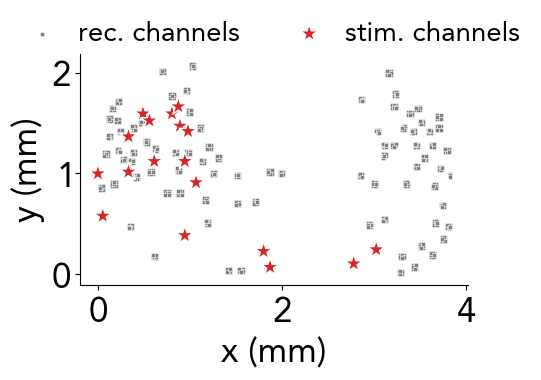

In [32]:
# most responsive channels
in_sign_bin = np.sum(ks_sign_bin,axis=0)

array_cols = ['tab:red' for i in range(len(indices))]
plot_map_rec(pos, 'grey', channel, def_chans, indices, array_cols, figsize=(5, 3), cbar_label='channel in-strength', dotcolor='lightgray',
                   dotsize=10, starsize = 180, text_dim = 20, dim = 60/3, font_DIM=25, ncol_leg=2, y_leg=1.25, cmap = None,
                   outf=path_imgs+'1.1channel_map_culture1.pdf', show_plot=show_plot)


### TE network

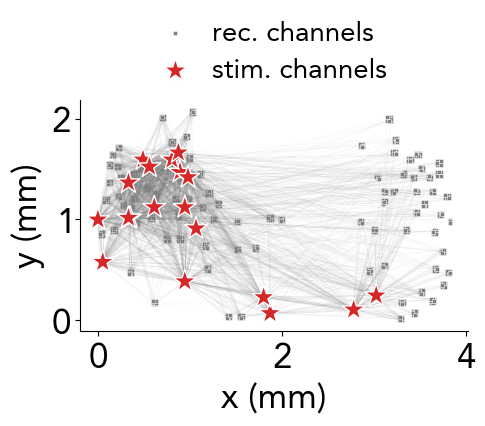

In [33]:
array_cols = ['tab:red' for i in range(len(indices))]
plot_map_rec_4(pos, TE_sign, 'grey', channel, def_chans, indices, array_cols, figsize=(5, 3), cbar_label='channel in-strength', dotcolor='lightgray',
               dotsize=10, starsize = 300, text_dim = 20, dim = 60/3, font_DIM=25, ncol_leg=1, y_leg=1.45, cmap = None,
               outf=path_imgs+'1.2_network_TE_culture1.pdf', show_plot=show_plot) #

### IC network

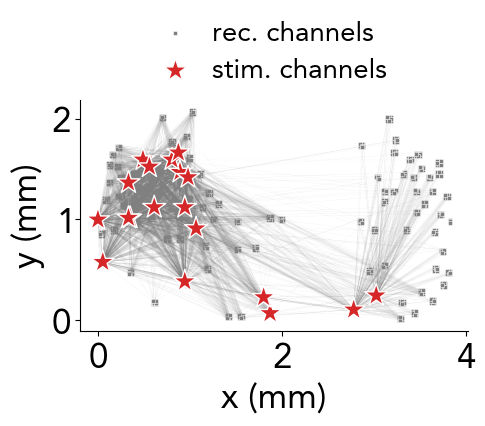

In [34]:
array_cols = ['tab:red' for i in range(len(indices))]
plot_map_rec_4(pos, ks_sign, 'grey', channel, def_chans, indices, array_cols, figsize=(5, 3), cbar_label='channel in-strength', dotcolor='lightgray',
                   dotsize=10, starsize = 300, text_dim = 20, dim = 60/3, font_DIM=25, ncol_leg=1, y_leg=1.45, cmap = None,
                   outf=path_imgs+'1.2_network_IC_culture1.pdf', show_plot=show_plot)

### Culture 2

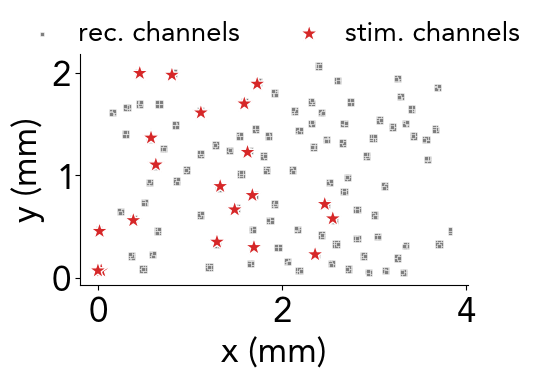

In [35]:
# most responsive channels
in_sign_bin = np.sum(ks_sign_bin2,axis=0)

array_cols = ['tab:red' for i in range(len(indices2))]
plot_map_rec(pos2, 'grey', channel2, def_chans2, indices2, array_cols, figsize=(5, 3), cbar_label='channel in-strength', dotcolor='lightgray',
                   dotsize=10, starsize = 180, text_dim = 20, dim = 60/3, font_DIM=25, ncol_leg=2, y_leg=1.25, cmap = None,
                   outf=path_imgs+'1.1channel_map_culture2.pdf', show_plot=show_plot)


### TE network

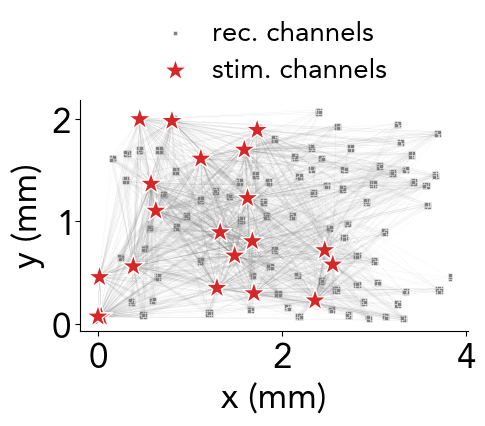

In [36]:
array_cols = ['tab:red' for i in range(len(indices2))]
plot_map_rec_4(pos2, TE_sign2, 'grey', channel2, def_chans2, indices2, array_cols, figsize=(5, 3), cbar_label='channel in-strength', dotcolor='lightgray',
               dotsize=10, starsize = 300, text_dim = 20, dim = 60/3, font_DIM=25, ncol_leg=1, y_leg=1.45, cmap = None,
               outf=path_imgs+'1.2_network_TE_culture1.pdf', show_plot=show_plot) #

### IC network

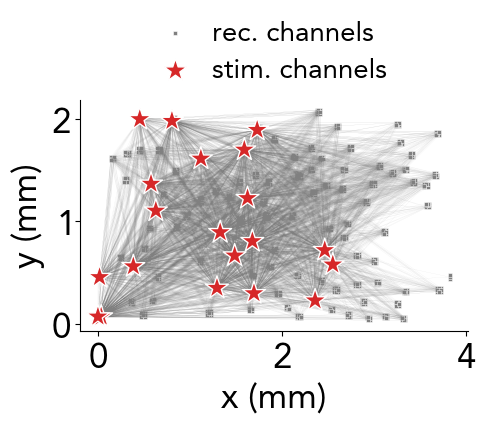

In [37]:
array_cols = ['tab:red' for i in range(len(indices2))]
plot_map_rec_4(pos2, ks_sign2, 'grey', channel2, def_chans2, indices2, array_cols, figsize=(5, 3), cbar_label='channel in-strength', dotcolor='lightgray',
                   dotsize=10, starsize = 300, text_dim = 20, dim = 60/3, font_DIM=25, ncol_leg=1, y_leg=1.45, cmap = None,
                   outf=path_imgs+'1.2_network_IC_culture2.pdf', show_plot=show_plot)

# Figure 3: Experimental Results

## a) Spatial Footprint

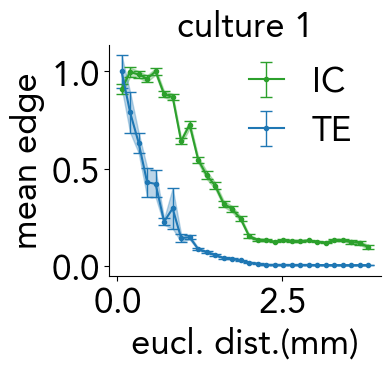

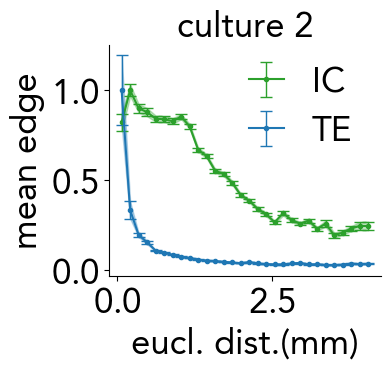

In [92]:
figsize    = (3.5,3)
linewidths = 1
nbins      = 30


for mats_list, Dmatrix, cult_lab, cult_save, pre_save in zip([[ks, TE],[ks2, TE2]],[Dmat,Dmat2], ['culture 1', 'culture 2'], ['culture1', 'culture2'], ['a1', 'a2']):

    fig,ax = plt.subplots(figsize=figsize)
    for mat,color,lab in zip(mats_list,['tab:green','tab:blue'], ['IC','TE']):
        
        D_v = Dmatrix.flatten()  # distance matrix     (x-azis)
        C_v = mat.flatten()   # connectivity matrix (y-axis)
    
        # Bin the x-axis values and compute means and standard deviations for y-values in each bin
        bins        = np.linspace(np.min(D_v), np.max(D_v), nbins + 1)
        bin_centers = 0.5 * (bins[1:] + bins[:-1])
        y_means     = np.zeros(nbins)
        y_stds      = np.zeros(nbins)
        y_counts    = np.zeros(nbins, dtype=int) # counting n samples in each bin (for sem)
        
        for j in range(nbins):
            bin_mask      = (D_v >= bins[j]) & (D_v < bins[j+1])
            y_vals_in_bin = C_v[bin_mask]
            n = y_vals_in_bin.size
            y_counts[j] = n
            if len(y_vals_in_bin) > 0:
                y_means[j] = np.mean(y_vals_in_bin)
                y_stds[j]  = np.std(y_vals_in_bin, ddof=1)
            else:
                y_means[j] = np.nan
                y_stds[j]  = np.nan
        
        y_sems  = np.divide(y_stds, np.sqrt(y_counts), out=np.full_like(y_stds, np.nan), where=y_counts>0)
        ymax    = np.nanmax(y_means) 
        y_means = y_means/ymax
        y_sems  = y_sems /ymax
        
        # Plot error bars instead of scatter
        ax.fill_between(bin_centers, y_means - y_sems, y_means + y_sems, color=color, alpha=0.3)
        ax.errorbar(bin_centers, y_means, yerr=y_sems, linestyle='-', fmt='o',  markersize=3, color=color, ecolor=color, elinewidth=linewidths, capsize=4, label=lab)
    
    ax.set_ylabel('mean edge', fontsize=DIM)
    ax.set_xlabel('eucl. dist.(mm)', fontsize=DIM)
    
    ax.legend(fontsize=DIM, ncol=1, loc='upper left', bbox_to_anchor=(0.4, 1.05), labelspacing=0.4, handletextpad=0.8, handlelength=1, frameon=False)
    pl.set_format(ax, axis_ticks='both', cbar=None, DIM=DIM)
    ax.set_title(cult_lab)
    fig.set_facecolor('none')
    
    plt.savefig(path_imgs + f'{pre_save}_spatialFootprint_{cult_save}.pdf', bbox_inches='tight')

    

## b) Edge strength distribution per sig./non-sig. connections

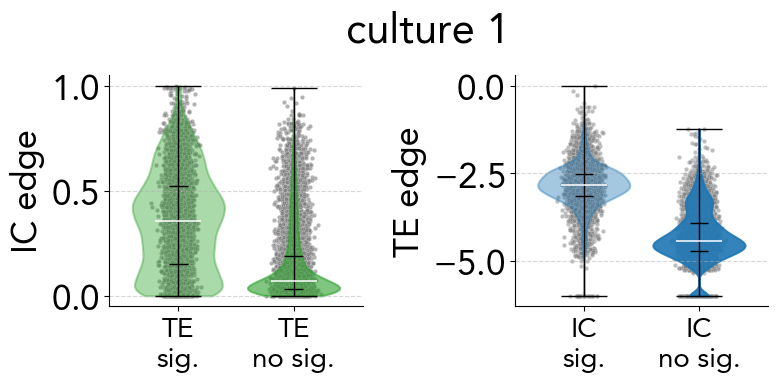

In [104]:
fig, axs = plt.subplots(1,2, figsize=(8.5, 3))

# ===== Violin plot: TE non-null vs null =====
ax=axs[0]
v1 = ks[TE_Pval<alpha_th]/np.max(ks.flatten())
v2 = ks[TE_Pval>=alpha_th]/np.max(ks.flatten())
violin_compare2(v1, v2, ax=ax, xlabels=('TE\nsig.', 'TE\nno sig.'), plot_dots=True, zorder_dots=0,
                point_color1='tab:grey', point_color2='tab:grey', point_alpha1=0.6, point_alpha2=0.6, point_size=10,
                point_edgecolor1='white', point_edgecolor2='white', point_edgewidth=0.2, jitter=0.06, widths=0.8,
                violin_facecolors=('tab:green', 'tab:green'), violin_edgecolors=('tab:green', 'tab:green'), violin_alphas=(0.4, 0.6),
                bar_color='k', bar_linewidth=1, bar_alpha=1, ylabel='IC edge',  color_median='white',  title=None,  grid_y=True)

# ===== Violin plot: TE non-null vs null =====
ax=axs[1]
v1 = np.log10(TE[ks_pval<alpha_th]/np.max(TE.flatten())+10**-6)
v2 = np.log10(TE[ks_pval>=alpha_th]/np.max(TE.flatten())+10**-6)
violin_compare2(v1, v2, ax=ax, xlabels=('IC\nsig.', 'IC\nno sig.'), plot_dots=True, zorder_dots=0,
                point_color1='tab:grey', point_color2='tab:grey', point_alpha1=0.5, point_alpha2=0.5, point_size=10,
                point_edgecolor1='white', point_edgecolor2='white', point_edgewidth=0.2, jitter=0.06, widths=0.8,
                violin_facecolors=('tab:blue', 'tab:blue'), violin_edgecolors=('tab:blue', 'tab:blue'), violin_alphas=(0.4, 0.9),
                bar_color='k', bar_linewidth=1, bar_alpha=1, ylabel='TE edge', color_median='white', title=None,  grid_y=True)
fig.subplots_adjust(wspace=0.6)
fig.suptitle('culture 1',y=1.1)
plt.savefig(path_imgs + f'b1_violin_IC_EC.pdf', bbox_inches='tight')


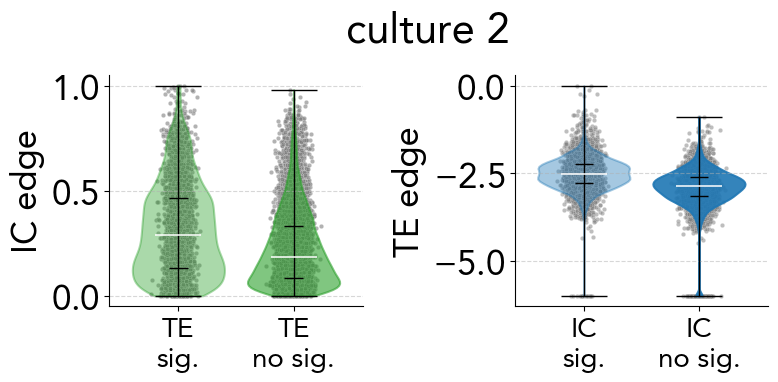

In [106]:
fig, axs = plt.subplots(1,2, figsize=(8.5, 3))

# ===== Violin plot: TE non-null vs null =====
ax=axs[0]
v1 = ks2[TE_Pval2<alpha_th]/np.max(ks2.flatten())
v2 = ks2[TE_Pval2>=alpha_th]/np.max(ks2.flatten())
violin_compare2(v1, v2, ax=ax, xlabels=('TE\nsig.', 'TE\nno sig.'), plot_dots=True, zorder_dots=0,
                point_color1='tab:grey', point_color2='tab:grey', point_alpha1=0.6, point_alpha2=0.6, point_size=10,
                point_edgecolor1='white', point_edgecolor2='white', point_edgewidth=0.2, jitter=0.06, widths=0.8,
                violin_facecolors=('tab:green', 'tab:green'), violin_edgecolors=('tab:green', 'tab:green'), violin_alphas=(0.4, 0.6),
                bar_color='k', bar_linewidth=1, bar_alpha=1, ylabel='IC edge',  color_median='white',  title=None,  grid_y=True)

# ===== Violin plot: TE non-null vs null =====
ax=axs[1]
v1 = np.log10(TE2[ks_pval2<alpha_th]/np.max(TE2.flatten())+10**-6)
v2 = np.log10(TE2[ks_pval2>=alpha_th]/np.max(TE2.flatten())+10**-6)
violin_compare2(v1, v2, ax=ax, xlabels=('IC\nsig.', 'IC\nno sig.'), plot_dots=True, zorder_dots=0,
                point_color1='tab:grey', point_color2='tab:grey', point_alpha1=0.5, point_alpha2=0.5, point_size=10,
                point_edgecolor1='white', point_edgecolor2='white', point_edgewidth=0.2, jitter=0.06, widths=0.8,
                violin_facecolors=('tab:blue', 'tab:blue'), violin_edgecolors=('tab:blue', 'tab:blue'), violin_alphas=(0.4, 0.9),
                bar_color='k', bar_linewidth=1, bar_alpha=1, ylabel='TE edge', color_median='white', title=None,  grid_y=True)
fig.subplots_adjust(wspace=0.6)
fig.suptitle('culture 2',y=1.1)
plt.savefig(path_imgs + f'b2_violin_IC_EC.pdf', bbox_inches='tight')


## c) Stim. channels: hubness predicts TE–IC similarity

In [107]:
mats = [TE, SC, XCov]
labs = ['TE','SC','XCov']

spearman, spearman_p = cc.correlate_source_fixed(mats, ks, exclude_zeros=False)
cpearson, cpearson_p = cc.correlate_source_fixed(mats, ks, exclude_zeros=False, pearson=True)

mats = [TE2, SC2, XCov2]
labs = ['TE','SC','XCov']

spearman_2, spearman_p_2 = cc.correlate_source_fixed(mats, ks2, exclude_zeros=False)
cpearson_2, cpearson_p_2 = cc.correlate_source_fixed(mats, ks2, exclude_zeros=False, pearson=True)


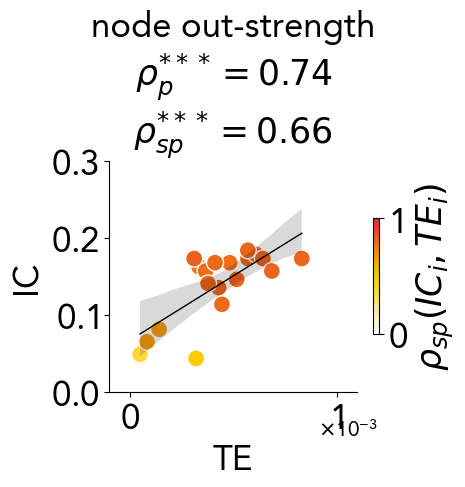

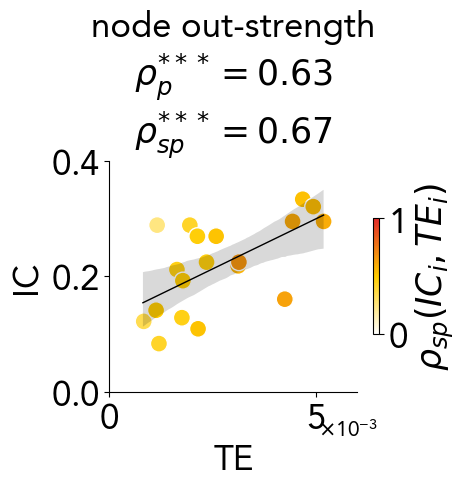

In [108]:
dotsize = 150
title = 'node out-strength'
cmap_r=truncate_cmap(plt.get_cmap(coldhot_cmap), minval=0.5, maxval=1)

###
TE_norm = TE/np.max(TE)
IC_norm = ks/np.max(ks)
col= spearman[0,:]
v1 = np.median(TE_norm, axis=-1)
v2 = np.median(IC_norm, axis=-1)
plot_scatterColor(v1,    v2,  col, xlabel=r'TE', ylabel=r'IC',  cbar_label=r'$\rho_{sp}(IC_i,TE_i)$', dotsize=dotsize, edgecolor='white', linewidths=1,  vmin_color=0, vmax_color=1, 
                  xmin=-0.0001, xmax=0.0011, ymin=-0.0, ymax=0.3,figsize=(4,3), reg_line=True, regcolor='k',  remove_outliers=False, ax = None,  cmap=cmap_r, title=title, alpha=1, 
                  outf=path_imgs + f'c1_scatter_out_culture1.pdf', show_plot=True)

###
TE_norm = TE2/np.max(TE2)
IC_norm = ks2/np.max(ks2)
col= spearman_2[0,:]
v1 = np.median(TE_norm, axis=-1)
v2 = np.median(IC_norm, axis=-1)
plot_scatterColor(v1,    v2,  col, xlabel=r'TE', ylabel=r'IC',  cbar_label=r'$\rho_{sp}(IC_i,TE_i)$', dotsize=dotsize, edgecolor='white', linewidths=1,  vmin_color=0, vmax_color=1, 
                  xmin=0, xmax=0.006, ymin=0, ymax=0.4, figsize=(4,3), reg_line=True, regcolor='k',  remove_outliers=False, ax = None,  cmap=cmap_r, title=title, alpha=1, 
                  outf=path_imgs + f'c2_scatter_out_culture2.pdf', show_plot=True)



Text(0.5, 1.6, 'culture 2')

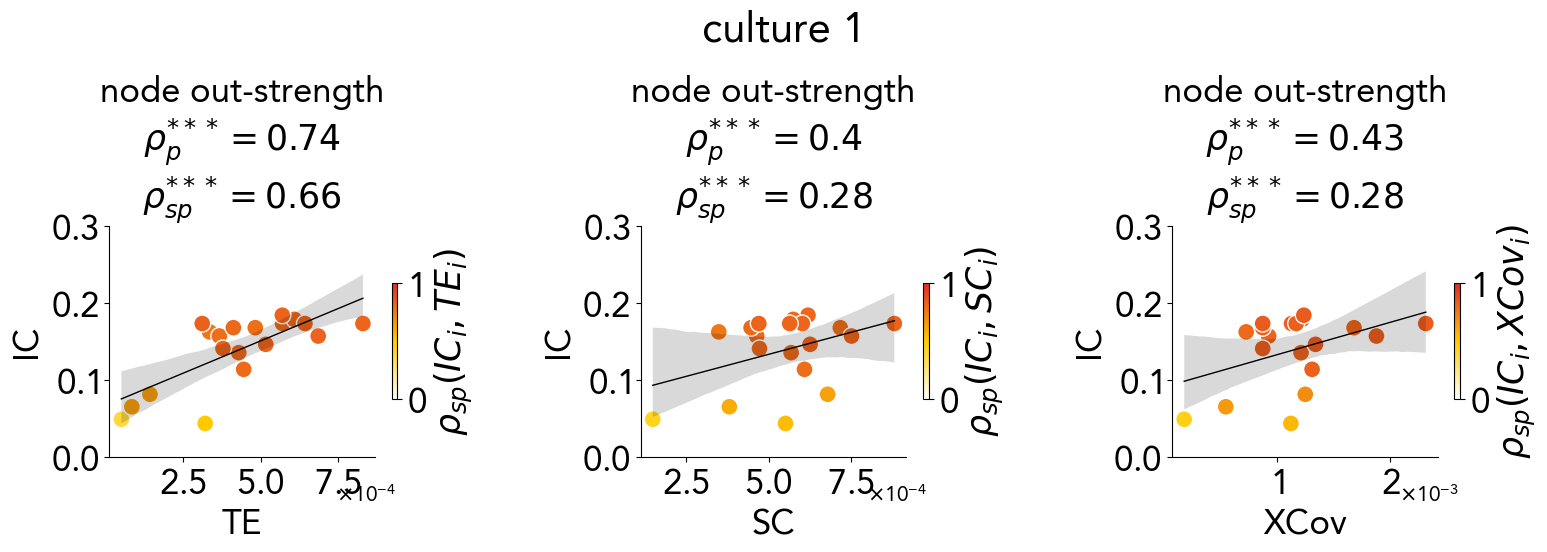

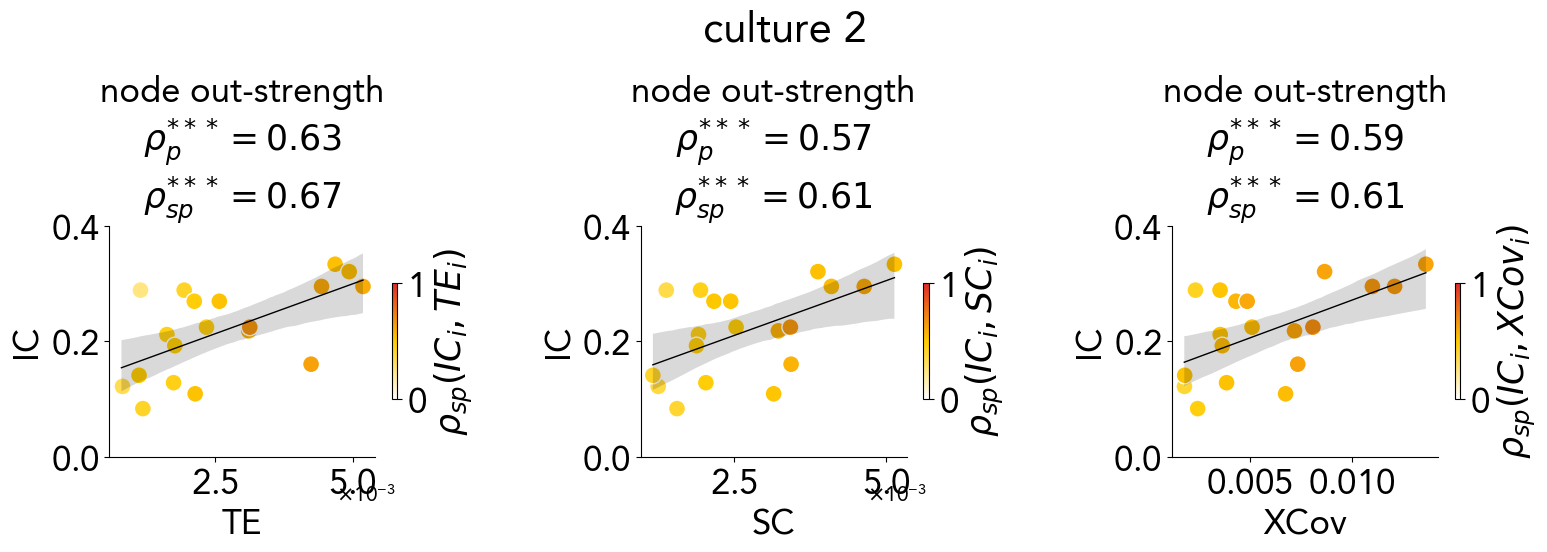

In [119]:
# comparison with other EC-metrics: TE vs. SC (XCorr with sign), XCovariance

dotsize = 150
title = 'node out-strength'
cmap_r=truncate_cmap(plt.get_cmap(coldhot_cmap), minval=0.5, maxval=1)


fig, axs = plt.subplots(1,3, figsize=(18,3))
for i, mat, lab in zip(np.arange(3), [TE,SC,XCov], ['TE','SC','XCov']):
    ax = axs[i]
    col= spearman[i,:]
    EC_norm = mat/np.max(mat); IC_norm = ks/np.max(ks)
    v1 = np.median(EC_norm, axis=-1); v2 = np.median(IC_norm, axis=-1)
    plot_scatterColor(v1,    v2,  col, xlabel=lab, ylabel=r'IC',  cbar_label=rf'$\rho_{{sp}}(IC_i,{lab}_i)$', dotsize=dotsize, edgecolor='white', linewidths=1,  vmin_color=0, vmax_color=1, 
                      ymin=-0.0, ymax=0.3, figsize=(4,3), reg_line=True, regcolor='k',  remove_outliers=False, ax = ax,  cmap=cmap_r, title=title, alpha=1, 
                      outf=None, show_plot=True)
fig.subplots_adjust(wspace=0.6)
fig.suptitle('culture 1',y=1.6)
    
###
fig, axs = plt.subplots(1,3, figsize=(18,3))
for i, mat2, lab in zip(np.arange(3), [TE2,SC2,XCov2], ['TE','SC','XCov']):
    ax = axs[i]
    col= spearman_2[i,:]
    EC_norm = mat2/np.max(mat2); IC_norm = ks2/np.max(ks2)
    v1 = np.median(EC_norm, axis=-1); v2 = np.median(IC_norm, axis=-1)
    plot_scatterColor(v1,    v2,  col, xlabel=lab, ylabel=r'IC',  cbar_label=rf'$\rho_{{sp}}(IC_i,{lab}_i)$', dotsize=dotsize, edgecolor='white', linewidths=1,  vmin_color=0, vmax_color=1, 
                       ymin=0, ymax=0.4, figsize=(4,3), reg_line=True, regcolor='k',  remove_outliers=False, ax = ax,  cmap=cmap_r, title=title, alpha=1, 
                      outf=None, show_plot=True)
fig.subplots_adjust(wspace=0.6)
fig.suptitle('culture 2',y=1.6)



## d) Stimulation channels: similarity of outgoing connectivity (TE vs IC)

In [120]:
def plot_map_stim_cmap(pos_, col_list, channel, def_chans, indices, array_col, cbar_label='', title=None, dotcolor='lightgrey',
                 dotsize=4.5, starsize = 1350, text_dim = 18, dim = 60, font_DIM=30, ncol_leg=2, y_leg=1.2, 
                 cmap='Reds', vmin=0, vmax=1, figsize=(23, 11), ax=None, outf : str = None, show_plot = True):
    
    pos = pos_[:,:]/1000
    
    if ax is None:
        fig,ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure() 
        outf=None
    
    # Full map of recording channels 
    scatter_rec = ax.scatter(pos[:, 0], pos[:, 1], s=dotsize/2, lw=0.4, marker='s', c=col_list, edgecolor='white',
                             label='rec.', zorder=0)
    
    # stimulation channels
    scatter = ax.scatter(pos[indices, 0], pos[indices, 1], c=array_col, edgecolor='k', lw=0.4, s=starsize, marker='*', alpha=1, zorder=1,
                         label='stim.', cmap=cmap, vmin=vmin, vmax=vmax)
    
    plt.xlabel('x (mm)', fontsize=font_DIM);    plt.ylabel('y (mm)', fontsize=font_DIM)
    pl.set_format(ax, axis_ticks='both', cbar=None, DIM=font_DIM)

    ax.legend(fontsize=font_DIM, ncol=ncol_leg, loc='upper center', bbox_to_anchor=(0.5, y_leg),
              labelspacing=0.4, handletextpad=0.8, handlelength=1., frameon=False)
    
    if title:
        ax.set_title(title)
    
    fig.set_facecolor('none')
    
    if outf is not None:
        plt.savefig(outf, bbox_inches='tight')
        if not show_plot:
            plt.close()

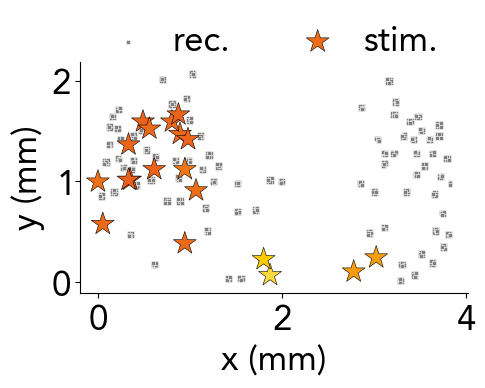

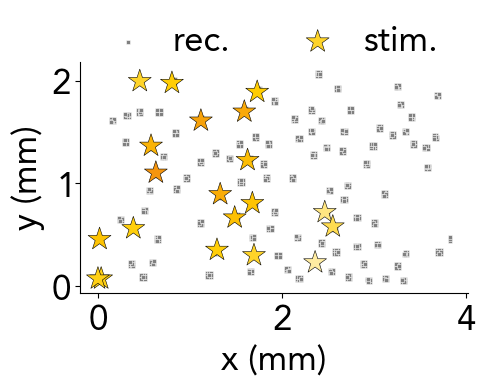

In [122]:


# most responsive channels
array_cols = spearman[0]
plot_map_stim_cmap(pos, 'grey', channel, def_chans, indices, array_cols, figsize=(5, 3), cbar_label='channel in-strength', dotcolor='lightgray',
                   dotsize=10, starsize = 300, text_dim = 20, dim = 60/3, font_DIM=25, ncol_leg=2, y_leg=1.3, cmap = cmap_r, vmin=0, vmax=1,
                   outf=path_imgs+'d1_channels_correlations_culture1.pdf', show_plot=show_plot)

# most responsive channels
array_cols = spearman_2[0]
plot_map_stim_cmap(pos2, 'grey', channel2, def_chans2, indices2, array_cols, figsize=(5, 3), cbar_label='channel in-strength', dotcolor='lightgray',
                   dotsize=10, starsize = 300, text_dim = 20, dim = 60/3, font_DIM=25, ncol_leg=2, y_leg=1.3, cmap = cmap_r, vmin=0, vmax=1,
                   outf=path_imgs+'d2_channels_correlations_culture2.pdf', show_plot=show_plot)


## e) IC-TE network similarity

In [134]:
def spear(x,y):
    from scipy.stats import spearmanr
    return spearmanr(x.flatten(), y.flatten())[0]

def pear(x,y):
    from scipy.stats import pearsonr
    return pearsonr(x.flatten(), y.flatten())[0]


### left panel: EC/IC whole edges, in-strenghts, out-strengths

In [140]:
#CULTURE 1
mats = [TE, SC, XCov] # EC is computed for TE, but also for 2 alternative metrics XCorr, and XCov
labs = ['TE','SC','XCov']
Scorr, Pcorr         = cc.corrMeasures(mats, ks, indices, compute_strength=False)
n=0
Scorr_in = np.zeros(3); Pcorr_in = np.zeros(3)
for i,mat in enumerate(mats):
    Scorr_in[i] = spear(np.median(mat,axis=n), np.median(ks,axis=n))
    Pcorr_in[i] = pear(np.median(mat,axis=n), np.median(ks,axis=n))
n=1
Scorr_out = np.zeros(3); Pcorr_out = np.zeros(3)
for i,mat in enumerate(mats):
    Scorr_out[i] = spear(np.median(mat,axis=n), np.median(ks,axis=n))
    Pcorr_out[i] = pear(np.median(mat,axis=n), np.median(ks,axis=n))

Scorr_all = np.vstack([Scorr, Scorr_in, Scorr_out])
Pcorr_all = np.vstack([Pcorr, Pcorr_in, Pcorr_out])
del Scorr, Scorr_in, Scorr_out, Pcorr, Pcorr_in, Pcorr_out

#CULTURE 2
mats = [TE2, SC2, XCov2]
labs = ['TE','SC','XCov']
Scorr, Pcorr         = cc.corrMeasures(mats, ks2, indices2, compute_strength=False)
n=0
Scorr_in = np.zeros(3); Pcorr_in = np.zeros(3)
for i,mat in enumerate(mats):
    Scorr_in[i] = spear(np.median(mat,axis=n), np.median(ks2,axis=n))
    Pcorr_in[i] = pear(np.median(mat,axis=n), np.median(ks2,axis=n))
n=1
Scorr_out = np.zeros(3); Pcorr_out = np.zeros(3)
for i,mat in enumerate(mats):
    Scorr_out[i] = spear(np.median(mat,axis=n), np.median(ks2,axis=n))
    Pcorr_out[i] = pear(np.median(mat,axis=n), np.median(ks2,axis=n))
print(Scorr_out)
Scorr_all_2 = np.vstack([Scorr, Scorr_in, Scorr_out])
Pcorr_all_2 = np.vstack([Pcorr, Pcorr_in, Pcorr_out])
del Scorr, Scorr_in, Scorr_out, Pcorr, Pcorr_in, Pcorr_out

[0.67269422 0.61469036 0.60640409]


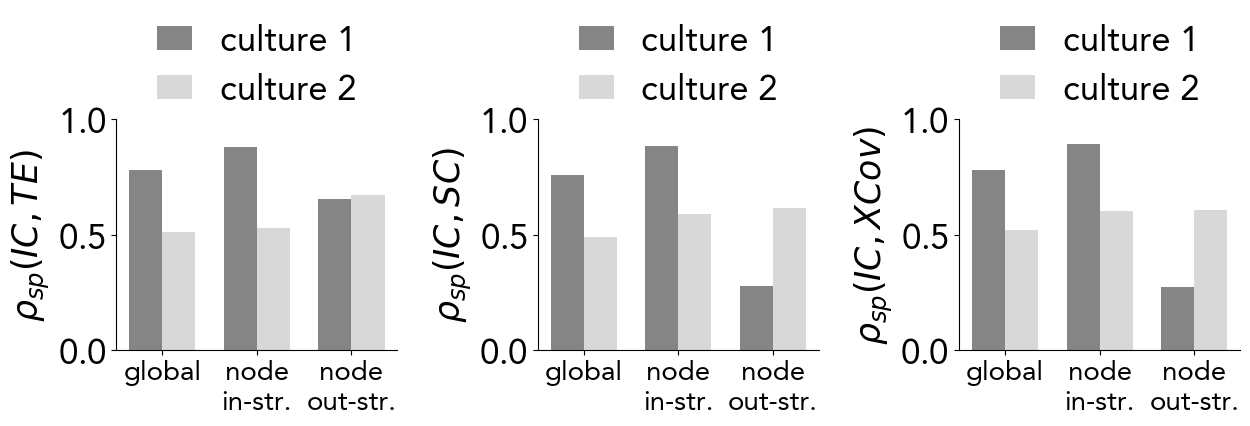

In [141]:
labels = ['global', 'node\nin-str.', 'node\nout-str.']
width = 0.35

fig,axs=plt.subplots(1,3,figsize=(14.5,3))

for i, lab in enumerate(labs):
    ax = axs[i]
    v1 = Scorr_all.T[i,:]
    v2 = Scorr_all_2.T[i,:]
    x = np.arange(len(v1))
    ax.bar(x - width/2, v1, width, color='tab:grey', alpha=0.95, label='culture 1')
    ax.bar(x + width/2, v2, width, color='tab:grey', alpha=0.3,  label='culture 2')
    
    pl.set_format(ax=ax, DIM=DIM, pwr_y_min=-2)
    ax.set_ylim(0,1)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=20)
    ax.set_ylabel(rf'$\rho_{{sp}}(IC,{lab})$')
    
    ax.legend(fontsize=DIM, ncol=1, loc='upper center', bbox_to_anchor=(0.5, 1.55),
              labelspacing=0.4, handletextpad=0.8, handlelength=1., frameon=False)
fig.subplots_adjust(wspace=0.5, hspace=0.5)
fig.set_facecolor('none')

plt.savefig(path_imgs + 'e.1_EC-IC_similarities_barplot.pdf', bbox_inches='tight')


### Right panel: Source-channels fixed – correlation between EC-IC outgoing edges

In [44]:
mats = [TE, SC, XCov]
labs = ['TE','SC','XCov']

spearman, spearman_p = cc.correlate_source_fixed(mats, ks, exclude_zeros=False)
cpearson, cpearson_p = cc.correlate_source_fixed(mats, ks, exclude_zeros=False, pearson=True)

mats = [TE2, SC2, XCov2]
labs = ['TE','SC','XCov']

spearman_2, spearman_p_2 = cc.correlate_source_fixed(mats, ks2, exclude_zeros=False)
cpearson_2, cpearson_p_2 = cc.correlate_source_fixed(mats, ks2, exclude_zeros=False, pearson=True)


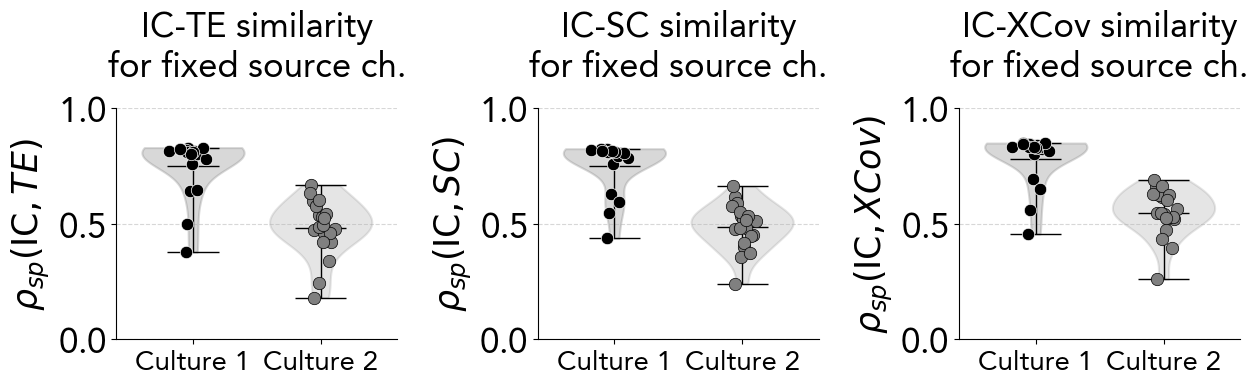

In [124]:
# ===== Plot =====
fig, axs = plt.subplots(1, 3, figsize=(14.5, 3))
for i, lab in enumerate(labs):
    v1 = spearman[i]
    v2 = spearman_2[i]
    ax = axs[i]

    violin_compare(v1, v2, ax=ax, xlabels=('Culture 1', 'Culture 2'), point_color1='k', point_alpha1=1,
                   point_color2='grey', point_alpha2=1, point_edgewidth=0.5, point_size=80,
                   point_edgecolor1='white', point_edgecolor2='k', jitter=0.08, widths=0.8,
                   violin_facecolors=('tab:grey', 'tab:grey'), violin_edgecolors=('tab:grey', 'tab:grey'), #92B9DD
                   violin_alphas=(0.3, 0.2), bar_color='k', bar_linewidth=1, bar_alpha=1, 
                   ylabel=rf'$\rho_{{sp}}(\mathrm{{IC}}, {lab})$', title=None, ylim=(0, 1), grid_y=True)
    ax.set_title(f'IC-{lab} similarity'+'\nfor fixed source ch.',y=1.1)
fig.subplots_adjust(wspace=0.5, hspace=0.5)
fig.set_facecolor('none')
plt.savefig(path_imgs + 'e.2_EC-IC_VIOLIN_source.pdf', bbox_inches='tight')


## Correcting for spatial dependency

In [126]:
def eval_fit_func(x, popt, fit_type='exp'):
    if fit_type == 'exp':
        return di.exp_func(x, *popt)
    elif fit_type == 'linear':
        return di.linear_func(x, *popt)
    elif fit_type == 'power':
        return di.power_func(x, *popt)
    elif fit_type == 'log':
        return di.log_func(x, *popt)
    elif fit_type == 'logit':
        return di.logistic_func(x, *popt)
    else:
        raise ValueError(f"Fit type {fit_type} not supported.")

def compute_residuals_from_popt(Dmat, matrices, metrics, params_dict, fit_type='exp'):
    resid_dict = {}
    x = Dmat.flatten()
    for ydata, metric in zip(matrices, metrics):
        y    = ydata.flatten()
        popt = params_dict[metric]

        y_pred = eval_fit_func(x, *popt, fit_type=fit_type)
        resid  = y - y_pred
        
        resid  = resid.reshape(Dmat.shape)
        y_pred = y_pred.reshape(Dmat.shape)
        
        resid_dict[metric] = resid

    return resid_dict


In [129]:
fit_type = 'exp'
# compute residuals
metrics = ['IC','TE', 'SC', 'XCov']
rm_quantiles=True
q = 0.0
zth=0
use_iqr=False
k=1.5


# CULTURE 1
out_popt_results={metric: [] for metric in metrics}
for ydata, metric in zip([ks, TE, SC, XCov], metrics):
    popt, _, _, _ = fit_and_plot(Dmat.flatten(), ydata.flatten(), fit_type=fit_type, rm_quantiles=rm_quantiles, use_iqr=use_iqr, 
                                       q=q, k=k, z_thresh=zth, return_mask=False, plot=False)
    out_popt_results[metric].append(popt)

out_residuals = compute_residuals_from_popt(Dmat, [ks, TE, SC, XCov], metrics, out_popt_results, fit_type=fit_type)


# CULTURE 2
out_popt_results2={metric: [] for metric in metrics}
for ydata, metric in zip([ks2, TE2, SC2, XCov2], metrics):
    popt, _, _, _ = fit_and_plot(Dmat2.flatten(), ydata.flatten(), fit_type=fit_type, rm_quantiles=rm_quantiles, use_iqr=use_iqr, 
                                       q=q, k=k, z_thresh=zth, return_mask=False, plot=False)
    out_popt_results2[metric].append(popt)

out_residuals2 = compute_residuals_from_popt(Dmat2, [ks2, TE2, SC2, XCov2], metrics, out_popt_results2, fit_type=fit_type)


## f) $\epsilon_{EC}$ – $\epsilon_{IC}$ network similarity

### left panel: $\epsilon_{EC}$ / $\epsilon_{IC}$ whole edges, in-strenghts, out-strengths

In [142]:
# RESIDUALS
#CULTURE 1
mats = [out_residuals['TE'], out_residuals['SC'], out_residuals['XCov']]
labs = [rf'\epsilon_{{TE}}',rf'\epsilon_{{SC}}',rf'\epsilon_{{XCov}}']
Scorr, Pcorr         = cc.corrMeasures(mats, out_residuals['IC'], indices, compute_strength=False)
n=0
Scorr_in = np.zeros(3); Pcorr_in = np.zeros(3)
for i,mat in enumerate(mats):
    Scorr_in[i] = spear(np.median(mat,axis=n), np.median(out_residuals['IC'],axis=n))
    Pcorr_in[i] = pear(np.median(mat,axis=n), np.median(out_residuals['IC'],axis=n))
n=1
Scorr_out = np.zeros(3); Pcorr_out = np.zeros(3)
for i,mat in enumerate(mats):
    Scorr_out[i] = spear(np.median(mat,axis=n), np.median(out_residuals['IC'],axis=n))
    Pcorr_out[i] = pear(np.median(mat,axis=n), np.median(out_residuals['IC'],axis=n))

Scorr_all = np.vstack([Scorr, Scorr_in, Scorr_out])
Pcorr_all = np.vstack([Pcorr, Pcorr_in, Pcorr_out])
del Scorr, Scorr_in, Scorr_out, Pcorr, Pcorr_in, Pcorr_out

#CULTURE 2
mats = [out_residuals2['TE'], out_residuals2['SC'], out_residuals2['XCov']]
labs = [rf'\epsilon_{{TE}}',rf'\epsilon_{{SC}}',rf'\epsilon_{{XCov}}']
Scorr, Pcorr         = cc.corrMeasures(mats, out_residuals2['IC'], indices2, compute_strength=False)
n=0
Scorr_in = np.zeros(3); Pcorr_in = np.zeros(3)
for i,mat in enumerate(mats):
    Scorr_in[i] = spear(np.median(mat,axis=n), np.median(out_residuals2['IC'],axis=n))
    Pcorr_in[i] = pear(np.median(mat,axis=n), np.median(out_residuals2['IC'],axis=n))
n=1
Scorr_out = np.zeros(3); Pcorr_out = np.zeros(3)
for i,mat in enumerate(mats):
    Scorr_out[i] = spear(np.median(mat,axis=n), np.median(out_residuals2['IC'],axis=n))
    Pcorr_out[i] = pear(np.median(mat,axis=n), np.median(out_residuals2['IC'],axis=n))
print(Scorr_out)
Scorr_all_2 = np.vstack([Scorr, Scorr_in, Scorr_out])
Pcorr_all_2 = np.vstack([Pcorr, Pcorr_in, Pcorr_out])
del Scorr, Scorr_in, Scorr_out, Pcorr, Pcorr_in, Pcorr_out

[0.54887218 0.52631579 0.51729323]


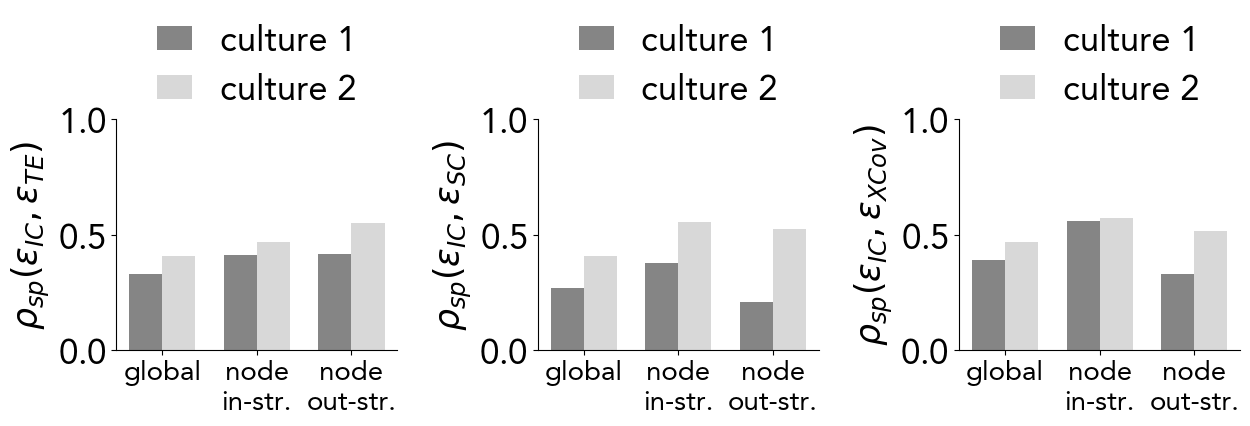

In [144]:
labels = ['global', 'node\nin-str.', 'node\nout-str.']
width = 0.35

fig,axs=plt.subplots(1,3,figsize=(14.5,3))

for i, lab in enumerate(labs):
    ax = axs[i]
    v1 = Scorr_all.T[i,:]
    v2 = Scorr_all_2.T[i,:]
    x = np.arange(len(v1))
    ax.bar(x - width/2, v1, width, color='tab:grey', alpha=0.95, label='culture 1')
    ax.bar(x + width/2, v2, width, color='tab:grey', alpha=0.3,  label='culture 2')
    
    pl.set_format(ax=ax, DIM=DIM, pwr_y_min=-2)
    ax.set_ylim(0,1)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=20)
    ax.set_ylabel(rf'$\rho_{{sp}}(\epsilon_{{IC}},{lab})$')
    
    ax.legend(fontsize=DIM, ncol=1, loc='upper center', bbox_to_anchor=(0.5, 1.55),
              labelspacing=0.4, handletextpad=0.8, handlelength=1., frameon=False)
fig.subplots_adjust(wspace=0.5, hspace=0.5)
fig.set_facecolor('none')

plt.savefig(path_imgs + 'f.1_residuals_EC-IC_similarities_barplot.pdf', bbox_inches='tight')


### Right panel: Source-channels fixed – correlation between $\epsilon_{EC}$ / $\epsilon_{IC}$ outgoing edges

In [155]:
mats = [out_residuals['TE'], out_residuals['SC'], out_residuals['XCov']]

spearman, spearman_p = cc.correlate_source_fixed(mats, out_residuals['IC'], exclude_zeros=False)
cpearson, cpearson_p = cc.correlate_source_fixed(mats, out_residuals['IC'], exclude_zeros=False, pearson=True)

mats = [out_residuals2['TE'], out_residuals2['SC'], out_residuals2['XCov']]
labs = [rf'$\epsilon_{{TE}}$',rf'$\epsilon_{{SC}}$',rf'$\epsilon_{{XCov}}$']

spearman_2, spearman_p_2 = cc.correlate_source_fixed(mats, out_residuals2['IC'], exclude_zeros=False)
cpearson_2, cpearson_p_2 = cc.correlate_source_fixed(mats, out_residuals2['IC'], exclude_zeros=False, pearson=True)


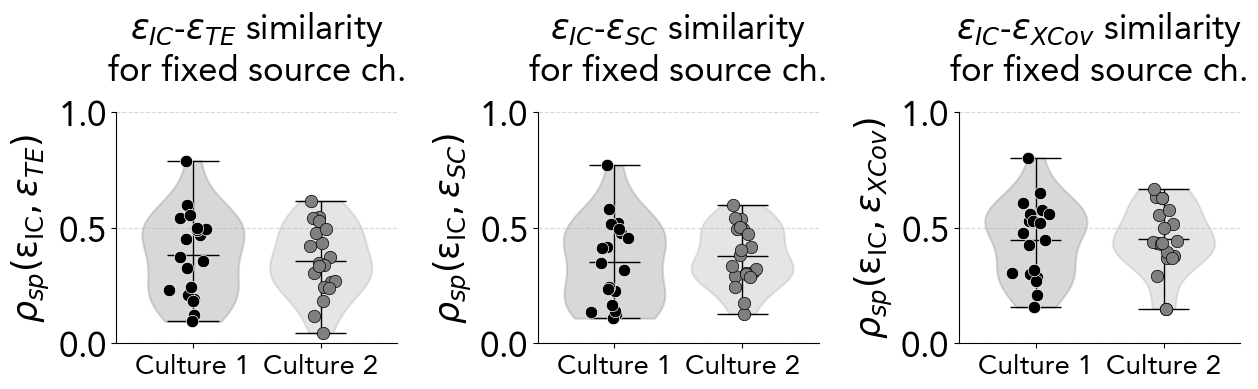

In [160]:
# ===== Plot =====
fig, axs = plt.subplots(1, 3, figsize=(14.5, 3))
for i, lab in enumerate(labs):
    v1 = spearman[i]
    v2 = spearman_2[i]
    ax = axs[i]

    violin_compare(v1, v2, ax=ax, xlabels=('Culture 1', 'Culture 2'), point_color1='k', point_alpha1=1,
                   point_color2='grey', point_alpha2=1, point_edgewidth=0.5, point_size=80,
                   point_edgecolor1='white', point_edgecolor2='k', jitter=0.08, widths=0.8,
                   violin_facecolors=('tab:grey', 'tab:grey'), violin_edgecolors=('tab:grey', 'tab:grey'), #92B9DD
                   violin_alphas=(0.3, 0.2), bar_color='k', bar_linewidth=1, bar_alpha=1, 
                   ylabel=rf'$\rho_{{sp}}(\mathrm{{\epsilon_{{IC}}}},${lab}$)$', title=None, ylim=(0, 1), grid_y=True)
    ax.set_title(fr'$\epsilon_{{IC}}$-{lab} similarity'+'\nfor fixed source ch.',y=1.1)
fig.subplots_adjust(wspace=0.5, hspace=0.5)
fig.set_facecolor('none')
plt.savefig(path_imgs + 'f.2_residuals_EC-IC_VIOLIN_source.pdf', bbox_inches='tight')


# Source channel hubs: measured (IC) vs. inferred (TE) perturbome

## g) perturbome maps

In [179]:
def plot_perturbome2(mat, map_coords, channel, indices, label='IC', stim_id=0, vmin=0, vmax=1, cmap='cool', log=False, 
                     rec_color='lightgrey', edgecolor='white', linewidths=0.04, star_color='tab:red', 
                     DIM=40, dotsize=22, starsize=1800, figsize=(20,11), ax=None, outf: str = None, show_plot=False):
    
    ch  = channel[indices[stim_id]]

    if ax is None:
        fig,ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()
    
    # map of recording channels as a background
    ax.scatter(map_coords[:,0], map_coords[:,1], s=dotsize/2, marker='s', c=rec_color, edgecolor=edgecolor, linewidths=linewidths,
               zorder=0)
    
    # scatter significant connections
    idxs = np.where(mat[stim_id, :] != 0)[0]
    values = mat[stim_id, idxs]
    if log:
        values = np.log10(values)
    # Clean up: remove NaN and clip out-of-bounds
    values = np.nan_to_num(values, nan=0.0, posinf=1.0, neginf=0.0)
    values = np.clip(values, vmin, vmax)
    
    scatter = ax.scatter(map_coords[idxs, 0], map_coords[idxs, 1], s=dotsize, marker='s', c=values, linewidths=linewidths,
                        edgecolor=edgecolor, cmap=cmap, vmin=vmin, vmax=vmax, zorder=1)

    # stim. channel
    ax.scatter(map_coords[channel==ch,0], map_coords[channel==ch,1], c='none', edgecolor='white',   linewidths=4.5, s=starsize, marker='*', zorder=2)
    ax.scatter(map_coords[channel==ch,0], map_coords[channel==ch,1], c='none', edgecolor=star_color, linewidths=2.5, s=starsize, marker='*', 
               label = f'stim. channel {indices[stim_id]}', zorder=3)

    # labels
    ax.set_xlabel('x  (mm)',fontsize=DIM)
    ax.set_ylabel('y  (mm)',fontsize=DIM)
    
    cbar = fig.colorbar(scatter, ax=ax)
    cbar.set_label(label=label, fontsize=DIM) 
    cbar.ax.tick_params(labelsize=DIM)
    
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.4), ncol=1, labelspacing=0.4, handletextpad=0.8, handlelength=1., frameon=False,
              fontsize=DIM)
    
    pl.set_format(ax=ax, pwr_x_min=-3, pwr_x_max=3, pwr_y_min=-2, pwr_y_max=2, axis_ticks = 'both', cbar = cbar, DIM = DIM)
    
    fig.set_facecolor('none')
    
    if outf is not None:
        plt.savefig(outf, bbox_inches='tight')
        if not show_plot:
            plt.close()
            

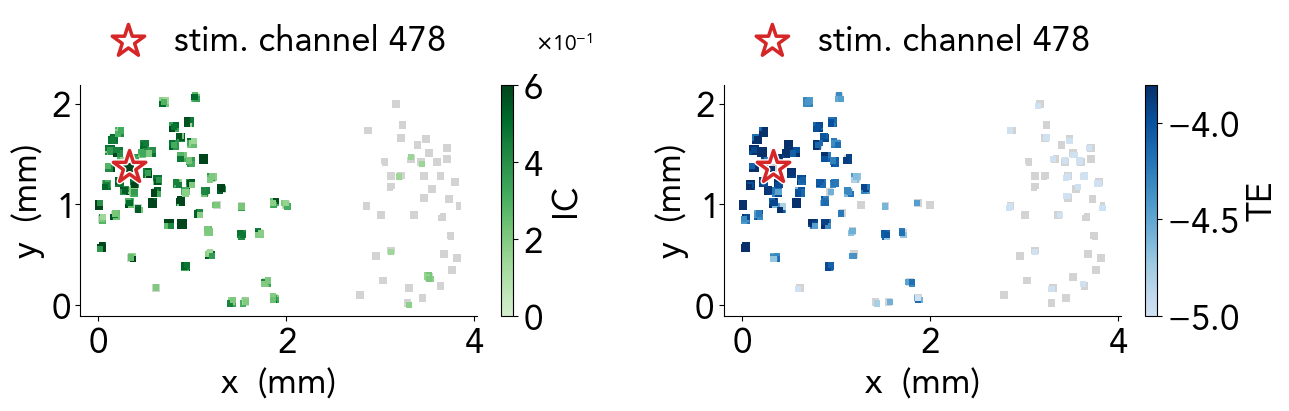

In [185]:
def truncate_cmap(cmap, minval=0.0, maxval=0.8, n=256):
    from matplotlib.colors import Normalize, LinearSegmentedColormap
    return LinearSegmentedColormap.from_list( f'{cmap.name}_trunc', cmap(np.linspace(minval, maxval, n)) )

cmap1=truncate_cmap(plt.get_cmap('Blues'), minval=0.2, maxval=1)
cmap2=truncate_cmap(plt.get_cmap('Reds'), minval=0.2, maxval=1)
cmap3=truncate_cmap(plt.get_cmap('Greys'), minval=0.2, maxval=1)
cmap_ks=truncate_cmap(plt.get_cmap('Greens'), minval=0.2, maxval=1)

#--------------------------------------------------------------------------------------------------------------------------------------

mats = [ ks_sign, TE_sign]
labs = [ 'IC', 'TE']
cmaps = [cmap_ks, cmap1]
vmins=[0, -5.] 
vmaxs=[0.6, -3.8]
logs = [False,True]

dss = [20,20]
list_idxs = [478]
for idx in list_idxs:
    i = np.where(indices==idx)[0][0]

    fig, axs = plt.subplots(1,2,figsize=(14.7,3))
    for ax, mat, lab, cmap, sc, vmin, vmax, log, dotsize in zip(axs, mats, labs, cmaps, ['tab:red', 'tab:red'], vmins, vmaxs, logs, dss):
        plot_perturbome2(mat,   pos/1000, channel, indices, label=lab, stim_id=i, vmin=vmin, vmax=vmax, cmap=cmap, 
                         rec_color='lightgrey', edgecolor='none', linewidths=0.04,
                         star_color=sc, ax = ax, DIM=25, dotsize=dotsize, starsize=600, log=log)
    fig.subplots_adjust(wspace=0.3, hspace=0.3)
    plt.savefig(path_imgs + f'g_perturbome_{indices[i]}.pdf', bbox_inches='tight')


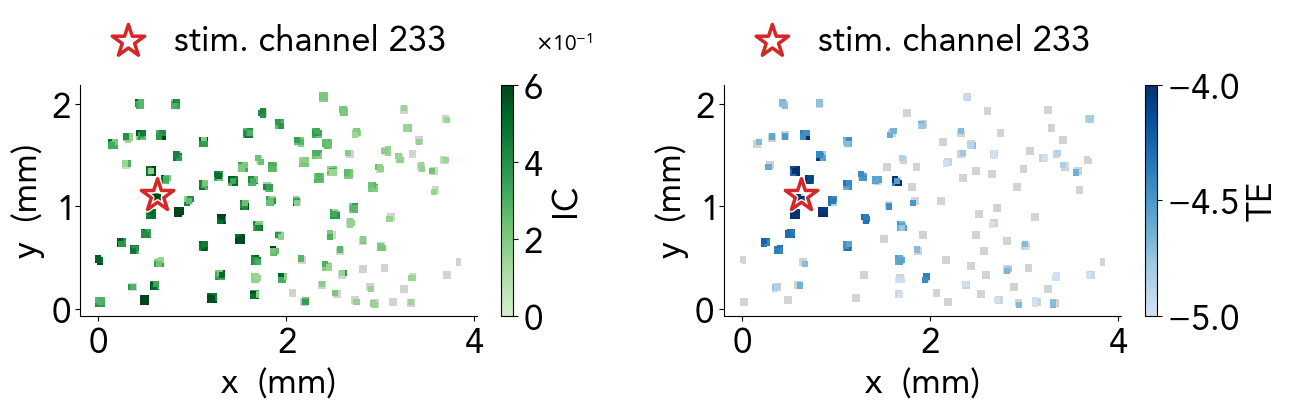

In [189]:
#--------------------------------------------------------------------------------------------------------------------------------------

mats = [ks_sign2, TE_sign2]
labs = ['IC', 'TE']
cmaps = [cmap_ks, cmap1]
vmins=[0, -5.] 
vmaxs=[0.6, -4]
logs = [False,True]

dss = [20,20]
list_idxs = [233]
for idx in list_idxs:
    i = np.where(indices2==idx)[0][0]

    fig, axs = plt.subplots(1,2,figsize=(14.7,3))
    for ax, mat, lab, cmap, sc, vmin, vmax, log, dotsize in zip(axs, mats, labs, cmaps, ['tab:red', 'tab:red'], vmins, vmaxs, logs, dss):
        plot_perturbome2(mat,   pos2/1000, channel2, indices2, label=lab, stim_id=i, vmin=vmin, vmax=vmax, cmap=cmap, 
                         rec_color='lightgrey', edgecolor='none', linewidths=0.04,
                         star_color=sc, ax = ax, DIM=25, dotsize=dotsize, starsize=600, log=log)
    fig.subplots_adjust(wspace=0.3, hspace=0.3)
    plt.savefig(path_imgs + f'g_perturbome_{indices2[i]}.pdf', bbox_inches='tight')


## h) Edge strength distribution per sig./non-sig. connections

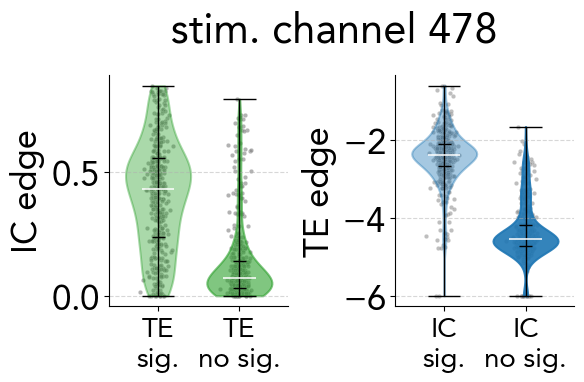

In [163]:
list_idxs = [478]
for idx in list_idxs:
    i = np.where(indices==idx)[0][0]
    
    Pval_TE = TE_Pval[i]
    Pval_ks = ks_pval[i]
    TE_norm = TE[i] / np.max(TE)
    ks_norm = ks[i] / np.max(ks)
    
    fig, axs = plt.subplots(1,2, figsize=(6., 3))
    
    # ===== Violin plot: TE non-null vs null =====
    ax=axs[0]
    v1 = ks_norm[Pval_TE<alpha_th]
    v2 = ks_norm[Pval_TE>=alpha_th]
    violin_compare2(v1, v2, ax=ax, xlabels=('TE\nsig.', 'TE\nno sig.'), plot_dots=True, zorder_dots=0,
                    point_color1='tab:grey', point_color2='tab:grey', point_alpha1=0.6, point_alpha2=0.6, point_size=10,
                    point_edgecolor1='white', point_edgecolor2='white', point_edgewidth=0.2, jitter=0.06, widths=0.8,
                    violin_facecolors=('tab:green', 'tab:green'), violin_edgecolors=('tab:green', 'tab:green'), violin_alphas=(0.4, 0.6),
                    bar_color='k', bar_linewidth=1, bar_alpha=1, ylabel='IC edge',  color_median='white',  title=None,  grid_y=True)
    
    # ===== Violin plot: TE non-null vs null =====
    ax=axs[1]
    v1 = np.log10(TE_norm[Pval_ks<alpha_th]+10**-6)
    v2 = np.log10(TE_norm[Pval_ks>=alpha_th]+10**-6)
    violin_compare2(v1, v2, ax=ax, xlabels=('IC\nsig.', 'IC\nno sig.'), plot_dots=True, zorder_dots=0,
                    point_color1='tab:grey', point_color2='tab:grey', point_alpha1=0.5, point_alpha2=0.5, point_size=10,
                    point_edgecolor1='white', point_edgecolor2='white', point_edgewidth=0.2, jitter=0.06, widths=0.8,
                    violin_facecolors=('tab:blue', 'tab:blue'), violin_edgecolors=('tab:blue', 'tab:blue'), violin_alphas=(0.4, 0.9),
                    bar_color='k', bar_linewidth=1, bar_alpha=1, ylabel='TE edge', color_median='white', title=None,  grid_y=True)
    fig.subplots_adjust(wspace=0.6)
    fig.suptitle(f'stim. channel {indices[i]}',y=1.1)
    plt.savefig(path_imgs + f'h1_violin_IC_EC_culture1_{indices[i]}.pdf', bbox_inches='tight')


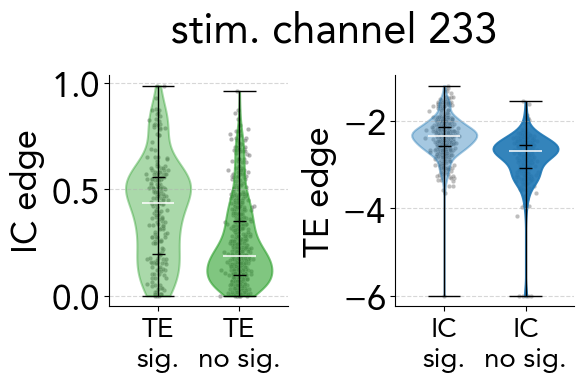

In [166]:
list_idxs = [233]
for idx in list_idxs:
    i = np.where(indices2==idx)[0][0]
    
    Pval_TE = TE_Pval2[i]
    Pval_ks = ks_pval2[i]
    TE_norm = TE2[i] / np.max(TE2)
    ks_norm = ks2[i] / np.max(ks2)
    
    fig, axs = plt.subplots(1,2, figsize=(6., 3))
    
    # ===== Violin plot: TE non-null vs null =====
    ax=axs[0]
    v1 = ks_norm[Pval_TE<alpha_th]
    v2 = ks_norm[Pval_TE>=alpha_th]
    violin_compare2(v1, v2, ax=ax, xlabels=('TE\nsig.', 'TE\nno sig.'), plot_dots=True, zorder_dots=0,
                    point_color1='tab:grey', point_color2='tab:grey', point_alpha1=0.6, point_alpha2=0.6, point_size=10,
                    point_edgecolor1='white', point_edgecolor2='white', point_edgewidth=0.2, jitter=0.06, widths=0.8,
                    violin_facecolors=('tab:green', 'tab:green'), violin_edgecolors=('tab:green', 'tab:green'), violin_alphas=(0.4, 0.6),
                    bar_color='k', bar_linewidth=1, bar_alpha=1, ylabel='IC edge',  color_median='white',  title=None,  grid_y=True)
    
    # ===== Violin plot: TE non-null vs null =====
    ax=axs[1]
    v1 = np.log10(TE_norm[Pval_ks<alpha_th]+10**-6)
    v2 = np.log10(TE_norm[Pval_ks>=alpha_th]+10**-6)
    violin_compare2(v1, v2, ax=ax, xlabels=('IC\nsig.', 'IC\nno sig.'), plot_dots=True, zorder_dots=0,
                    point_color1='tab:grey', point_color2='tab:grey', point_alpha1=0.5, point_alpha2=0.5, point_size=10,
                    point_edgecolor1='white', point_edgecolor2='white', point_edgewidth=0.2, jitter=0.06, widths=0.8,
                    violin_facecolors=('tab:blue', 'tab:blue'), violin_edgecolors=('tab:blue', 'tab:blue'), violin_alphas=(0.4, 0.9),
                    bar_color='k', bar_linewidth=1, bar_alpha=1, ylabel='TE edge', color_median='white', title=None,  grid_y=True)
    fig.subplots_adjust(wspace=0.6)
    fig.suptitle(f'stim. channel {indices2[i]}',y=1.1)
    plt.savefig(path_imgs + f'h2_violin_IC_EC_culture2_{indices2[i]}.pdf', bbox_inches='tight')


## i) IC-EC edges relation

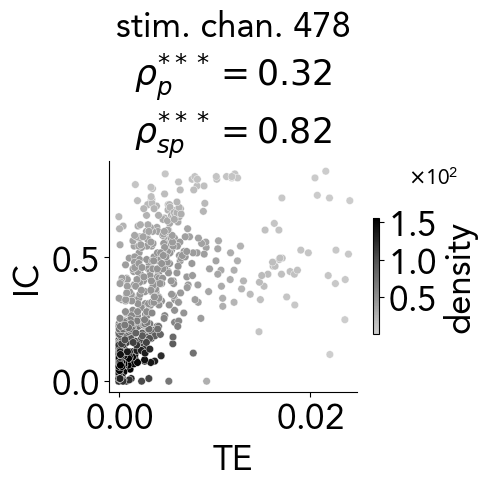

In [167]:
cmap = truncate_cmap(plt.get_cmap('Greys'), minval=0.3, maxval=1)

TE_norm = TE/np.max(TE.flatten())
IC_norm = ks/np.max(ks.flatten())
list_idxs = indices
for idx in [478]:
    i = np.where(indices==idx)[0][0]
    v1 = TE_norm[i]
    v2 = IC_norm[i]
    plot_scatter(v1, v2, xlabel='TE', ylabel='IC', dotsize=30, edgecolor='white', linewidths=0.3, 
                 remove_outliers=False, xmin=-0.001, xmax=0.025, figsize=(4,3), #ymin=-0.05, ymax=1, 
                 cmap=cmap, title=f'stim. chan. {indices[i]}', alpha=1, outf=path_imgs+f'_scatter_{indices[i]}.pdf', show_plot=True)
    #ax.scatter(TE_norm[i], IC_norm[i], s=2, c='red')

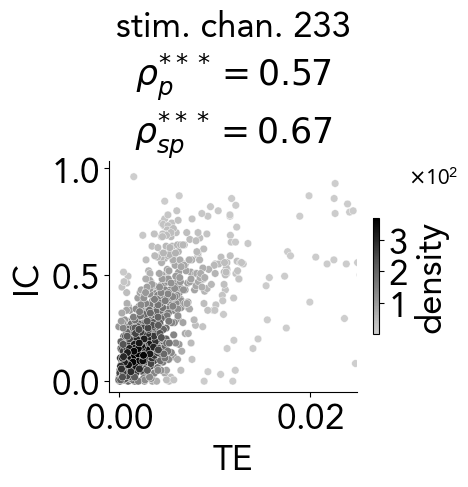

In [171]:
cmap = truncate_cmap(plt.get_cmap('Greys'), minval=0.3, maxval=1)

TE_norm = TE2/np.max(TE2.flatten())
IC_norm = ks2/np.max(ks2.flatten())
list_idxs = indices
for idx in [233]:
    i = np.where(indices2==idx)[0][0]
    v1 = TE_norm[i]
    v2 = IC_norm[i]
    plot_scatter(v1, v2, xlabel='TE', ylabel='IC', dotsize=30, edgecolor='white', linewidths=0.3, 
                 remove_outliers=False, xmin=-0.001, xmax=0.025, figsize=(4,3), #ymin=-0.05, ymax=1, 
                 cmap=cmap, title=f'stim. chan. {indices2[i]}', alpha=1, outf=path_imgs+f'_scatter_{indices[i]}.pdf', show_plot=True)
    #ax.scatter(TE_norm[i], IC_norm[i], s=2, c='red')

## Single-channel Footprints

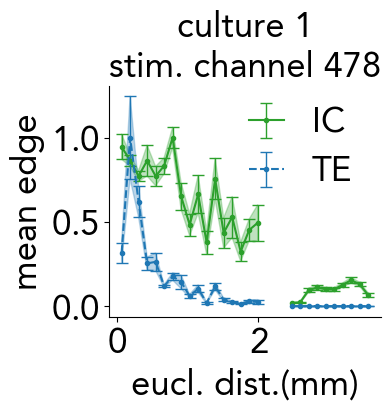

In [177]:
figsize=(3.5,3)

linewidths=1
nbins=30

list_idxs = [478]
for idx in list_idxs:
    i = np.where(indices==idx)[0][0]

    fig,ax = plt.subplots(figsize=figsize)
    for mat,color,lab,linestyle in zip([ks[i], TE[i]],['tab:green','tab:blue'], ['IC','TE'],['-','--']):
        
        D_v = Dmat[i].flatten()    # distance matrix     (x-azis)
        C_v = mat.flatten()   # connectivity matrix (y-axis)
    
        # Bin the x-axis values and compute means and standard deviations for y-values in each bin
        bins        = np.linspace(np.min(D_v), np.max(D_v), nbins + 1)
        bin_centers = 0.5 * (bins[1:] + bins[:-1])
        y_means     = np.zeros(nbins)
        y_stds      = np.zeros(nbins)
        y_counts    = np.zeros(nbins, dtype=int) # counting n samples in each bin (for sem)
        
        for j in range(nbins):
            bin_mask      = (D_v >= bins[j]) & (D_v < bins[j+1])
            y_vals_in_bin = C_v[bin_mask]
            n = y_vals_in_bin.size
            y_counts[j] = n
            if len(y_vals_in_bin) > 0:
                y_means[j] = np.mean(y_vals_in_bin)
                y_stds[j]  = np.std(y_vals_in_bin, ddof=1)
            else:
                y_means[j] = np.nan
                y_stds[j]  = np.nan
        
        y_sems  = np.divide(y_stds, np.sqrt(y_counts), out=np.full_like(y_stds, np.nan), where=y_counts>0)
        ymax    = np.nanmax(y_means) 
        y_means = y_means/ymax
        y_sems  = y_sems /ymax
        
        # Plot error bars instead of scatter
        ax.fill_between(bin_centers, y_means - y_sems, y_means + y_sems, color=color, alpha=0.3)
        #ax.plot(bin_centers, y_means,'-', color=color, lw=2)#, edgecolor=edgecolor,markersize=10)
        ax.errorbar(bin_centers, y_means, yerr=y_sems, linestyle=linestyle, fmt='o',  markersize=3, color=color, ecolor=color, elinewidth=linewidths, capsize=4, label=lab)
    
    ax.set_ylabel('mean edge', fontsize=DIM)
    ax.set_xlabel('eucl. dist.(mm)', fontsize=DIM)
    
    ax.legend(fontsize=DIM, ncol=1, loc='upper left', bbox_to_anchor=(0.4, 1.05), labelspacing=0.4, handletextpad=0.8, handlelength=1, frameon=False)
    pl.set_format(ax, axis_ticks='both', cbar=None, DIM=DIM)
    ax.set_title('culture 1\n'+f'stim. channel {indices[i]}')

    fig.set_facecolor('none')
    
    plt.savefig(path_imgs + f'5.2_spatialFootprint_{indices[i]}.pdf', bbox_inches='tight')

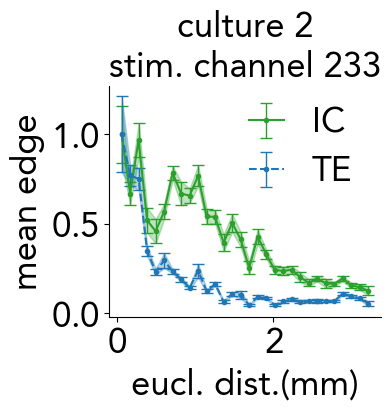

In [176]:
figsize=(3.5,3)

linewidths=1
nbins=30

list_idxs = [233]
for idx in list_idxs:
    i = np.where(indices2==idx)[0][0]

    fig,ax = plt.subplots(figsize=figsize)
    for mat,color,lab,linestyle in zip([ks2[i], TE2[i]],['tab:green','tab:blue'], ['IC','TE'],['-','--']):
        
        D_v = Dmat2[i].flatten()    # distance matrix     (x-azis)
        C_v = mat.flatten()   # connectivity matrix (y-axis)
    
        # Bin the x-axis values and compute means and standard deviations for y-values in each bin
        bins        = np.linspace(np.min(D_v), np.max(D_v), nbins + 1)
        bin_centers = 0.5 * (bins[1:] + bins[:-1])
        y_means     = np.zeros(nbins)
        y_stds      = np.zeros(nbins)
        y_counts    = np.zeros(nbins, dtype=int) # counting n samples in each bin (for sem)
        
        for j in range(nbins):
            bin_mask      = (D_v >= bins[j]) & (D_v < bins[j+1])
            y_vals_in_bin = C_v[bin_mask]
            n = y_vals_in_bin.size
            y_counts[j] = n
            if len(y_vals_in_bin) > 0:
                y_means[j] = np.mean(y_vals_in_bin)
                y_stds[j]  = np.std(y_vals_in_bin, ddof=1)
            else:
                y_means[j] = np.nan
                y_stds[j]  = np.nan
        
        y_sems  = np.divide(y_stds, np.sqrt(y_counts), out=np.full_like(y_stds, np.nan), where=y_counts>0)
        ymax    = np.nanmax(y_means) 
        y_means = y_means/ymax
        y_sems  = y_sems /ymax
        
        # Plot error bars instead of scatter
        ax.fill_between(bin_centers, y_means - y_sems, y_means + y_sems, color=color, alpha=0.3)
        #ax.plot(bin_centers, y_means,'-', color=color, lw=2)#, edgecolor=edgecolor,markersize=10)
        ax.errorbar(bin_centers, y_means, yerr=y_sems, linestyle=linestyle, fmt='o',  markersize=3, color=color, ecolor=color, elinewidth=linewidths, capsize=4, label=lab)
    
    ax.set_ylabel('mean edge', fontsize=DIM)
    ax.set_xlabel('eucl. dist.(mm)', fontsize=DIM)
    
    ax.legend(fontsize=DIM, ncol=1, loc='upper left', bbox_to_anchor=(0.4, 1.05), labelspacing=0.4, handletextpad=0.8, handlelength=1, frameon=False)
    pl.set_format(ax, axis_ticks='both', cbar=None, DIM=DIM)
    ax.set_title('culture 2\n'+f'stim. channel {indices2[i]}')
    fig.set_facecolor('none')
    
    plt.savefig(path_imgs + f'5.2_spatialFootprint_{indices2[i]}.pdf', bbox_inches='tight')